<!-- ✅ UNIVERSITY LOGO — replace src with your logo URL or base64 -->
  <img src="https://cdn.remotexs.co/institute-logos/uz.png"
       alt="University Logo"
       style="height:300px; width:auto; margin-bottom:auto; display:block; margin-left:auto; margin-right:auto;">



| Field             | Detail            |
|:------------------|:------------------|
| **Name**          | MARTHA CHARANGWA R|
| **Registration**  | R2424205          |
| **Program**       | HDSC              |
| **Course Code**   | HASTS21           |

# Modeling Non-Stationarity and Finding an Equilibrium
## Cointegration & Vector Error-Correction Model (VECM)
### Apple Inc. (AAPL) · Microsoft Corp. (MSFT) · Alphabet Inc. (GOOGL)

---

|--FIELD|  DETAILS
|---|---|
| **Tickers** | AAPL, MSFT, GOOGL |
| **Source** | Yahoo Finance (via `yfinance`) |
| **Frequency** | Daily (business days) |
| **Period** | January 1 2018 – December 31 2025 |
| **Observations** | ~2,088 trading days |
| **Units** | USD adjusted closing price → log-transformed |



| # | Section |
|---|---|
| 1 | **Definition** — equations and terms |
| 2 | **Dataset** — why this data works |
| 3 | **Diagram** — exploratory plots |
| 4 | **Demonstration** — run the model, calibrate, interpret parameters |
| 5 | **Diagnosis** — diagnostic plots |
| 6 | **Damage** — problems the model reveals |
| 7 | **Directions** — how to improve; **Deployment** — how to use it |

---
## Setup — Install & Import

In [ ]:
# Install packages not pre-loaded in Colab
!pip install yfinance statsmodels --quiet
print('Installation complete.')

Installation complete.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Statsmodels
from statsmodels.tsa.stattools   import adfuller, coint
from statsmodels.tsa.vector_ar.vecm  import coint_johansen, VECM
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.regression.linear_model import OLS
from statsmodels.tools           import add_constant
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import yfinance as yf

# ── Consistent plot style throughout ─────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titleweight'  : 'bold',
    'axes.titlesize'    : 12,
    'figure.dpi'        : 120,
})
BLUE   = '#1f4e79'
ORANGE = '#c55a11'
GREEN  = '#375623'
C3     = [BLUE, '#2e75b6', '#70ad47']   # AAPL, MSFT, GOOGL
print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
# ── Download Data from Yahoo Finance ─────────────────────────────────────────
TICKERS    = ['AAPL', 'MSFT', 'GOOGL']
START_DATE = '2018-01-01'
END_DATE   = '2025-12-31'

print(f'Downloading daily adjusted closing prices: {TICKERS}')
print(f'Period: {START_DATE}  to  {END_DATE}\n')

try:
    raw = yf.download(TICKERS, start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)
    df = (raw['Close'] if isinstance(raw.columns, pd.MultiIndex)
          else raw)[TICKERS].dropna()
    assert len(df) > 200
    SRC = 'Yahoo Finance — live download'
except Exception as err:
    print(f'Live download failed ({err}).  Using reproducible synthetic data.')
    np.random.seed(42)
    idx   = pd.date_range(START_DATE, END_DATE, freq='B')
    n     = len(idx)
    trend = np.cumsum(np.random.normal(0, 0.8, n))
    df = pd.DataFrame({
        'AAPL' : 170  + 1.00*trend + np.cumsum(np.random.normal(0, 0.3, n)),
        'MSFT' : 85   + 0.85*trend + np.cumsum(np.random.normal(0, 0.3, n)),
        'GOOGL': 1050 + 2.50*trend + np.cumsum(np.random.normal(0, 0.8, n)),
    }, index=idx)
    SRC = 'Synthetic — seed=42, common I(1) trend'

# Log-transform for variance stabilisation
log_df = np.log(df)
log_df.columns = ['ln(AAPL)', 'ln(MSFT)', 'ln(GOOGL)']

print(f'Source        : {SRC}')
print(f'Period        : {df.index[0].date()}  to  {df.index[-1].date()}')
print(f'Observations  : {len(df):,}  trading days')
print(f'Tickers       : {list(df.columns)}\n')
display(df.describe().round(2).rename_axis('Statistic'))

Period: 2018-01-01  to  2025-12-31

Source        : Yahoo Finance — live download
Period        : 2018-01-02  to  2025-12-30
Observations  : 2,010  trading days
Tickers       : ['AAPL', 'MSFT', 'GOOGL']



Ticker,AAPL,MSFT,GOOGL
Statistic,,,
count,2010.00,2010.00,2010.00
mean,135.32,263.48,114.31
std,66.70,125.59,54.16
min,33.77,78.01,48.83
25%,64.32,145.36,64.17
50%,142.80,250.85,108.85
75%,182.69,368.22,143.26
max,285.92,539.83,323.00


In [ ]:
print('''First 5 rows of the log-transformed data (ln USD):
''')
display(log_df.head())

First 5 rows of the log-transformed data (ln USD):



,ln(AAPL),ln(MSFT),ln(GOOGL)
Date,,,
2018-01-02,3.696455,4.367805,3.974446
2018-01-03,3.696281,4.372448,3.991363
2018-01-04,3.700915,4.381211,3.995240
2018-01-05,3.712236,4.393534,4.008413
2018-01-08,3.708515,4.394553,4.011938


---
## Section 1 — Definition
*Technical definitions using formulas and equations for every term in the model.*


### 1.1  Non-Stationarity and the I(1) Process

A time series $y_t$ is **weakly stationary** when its first two moments are time-invariant:
$$E[y_t] = \mu, \qquad \text{Var}(y_t) = \sigma^2 < \infty, \qquad \text{Cov}(y_t,\, y_{t-k}) = \gamma(k) \quad \forall\, t$$

A series is **integrated of order one**, written $y_t \sim I(1)$, when it is non-stationary in levels but its first difference $\Delta y_t = y_t - y_{t-1}$ is stationary $I(0)$. The prototypical I(1) process is the **random walk**:
$$y_t = y_{t-1} + \varepsilon_t, \qquad \varepsilon_t \overset{iid}{\sim} (0,\sigma^2)$$
Its variance $\text{Var}(y_t) = t\sigma^2$ grows without bound, so the series never reverts to a fixed level.

### 1.2  Augmented Dickey-Fuller (ADF) Test

The ADF test evaluates $H_0: \delta = 0$ (unit root, non-stationary) vs $H_1: \delta < 0$ (stationary) in:
$$\Delta y_t = \alpha + \delta\, y_{t-1} + \sum_{j=1}^{p} \phi_j\, \Delta y_{t-j} + \varepsilon_t$$
where $\alpha$ is a constant drift, $\delta$ is the key coefficient, $\phi_j$ are short-run dynamics, and $p$ is the lag length chosen by the AIC. **Rejecting $H_0$** means the series is stationary.

### 1.3  Cointegration

A $p$-vector $\mathbf{Y}_t = (y_{1t}, y_{2t}, \ldots, y_{pt})'$ of $I(1)$ series is **cointegrated** CI(1,1) if there exists a non-zero vector $\boldsymbol{\beta}$ such that:
$$\boldsymbol{\beta}'\mathbf{Y}_t \sim I(0)$$
The vector $\boldsymbol{\beta}$ is the **cointegrating vector** and defines the long-run equilibrium. The scalar $ECT_t = \boldsymbol{\beta}'\mathbf{Y}_t$ is the **error-correction term** (ECT) — the deviation from equilibrium at time $t$. Because ECT is $I(0)$, deviations are mean-reverting: the series cannot diverge permanently.

### 1.4  Johansen Trace Test

The Johansen (1991) procedure determines the number of linearly independent cointegrating vectors — the **cointegrating rank** $r$ — by testing the rank of the long-run impact matrix $\boldsymbol{\Pi}$. The **trace statistic** tests $H_0: \text{rank}(\boldsymbol{\Pi}) \leq r$ against $H_1: \text{rank}(\boldsymbol{\Pi}) > r$:
$$\lambda_{\text{trace}}(r) = -T \sum_{i=r+1}^{p} \ln\left(1 - \hat{\lambda}_i\right)$$
where $T$ is the number of observations and $\hat{\lambda}_i$ are the ordered eigenvalues of $\boldsymbol{\Pi}$. Tests proceed sequentially from $r=0$ upward; the first $H_0$ that is **not rejected** gives the estimated rank.

### 1.5  Vector Error-Correction Model (VECM)

Once cointegration is established (rank $r \geq 1$), the VECM models both the **short-run dynamics** and the **long-run equilibrium correction** in a single unified system:

$$\boxed{\Delta\mathbf{Y}_t = \underbrace{\boldsymbol{\alpha}\boldsymbol{\beta}'\mathbf{Y}_{t-1}}_{\text{long-run error correction}} + \sum_{j=1}^{k-1}\boldsymbol{\Gamma}_j\,\Delta\mathbf{Y}_{t-j} + \boldsymbol{\varepsilon}_t}$$

| Symbol | Dimension | Definition |
|:------:|:---------:|:----------|
| $\boldsymbol{\beta}$ | $p \times r$ | **Cointegrating vectors** — the long-run equilibrium weights |
| $\boldsymbol{\alpha}$ | $p \times r$ | **Speed-of-adjustment** (loading) coefficients — how fast each series corrects deviations |
| $\boldsymbol{\Gamma}_j$ | $p \times p$ | Short-run lag matrices — transient dynamics |
| $\boldsymbol{\varepsilon}_t$ | $p \times 1$ | Multivariate white noise: $\boldsymbol{\varepsilon}_t \sim MN(\mathbf{0}, \boldsymbol{\Sigma})$ |
| $\boldsymbol{\Pi} = \boldsymbol{\alpha}\boldsymbol{\beta}'$ | $p \times p$ | Long-run impact matrix; its rank $= r$ (number of equilibria) |

### 1.6  Description

Non-stationarity in financial prices means each series wanders without a fixed mean, driven by accumulated random shocks.  
Cointegration reveals whether multiple non-stationary series nevertheless share a stable long-run equilibrium — a hidden attractor — and the VECM quantifies how quickly each series corrects back toward that equilibrium when disturbed.


---
## Section 2 — Dataset Justification
*Why these three series, this frequency, and this time period work well for the chosen model.*


### Why AAPL, MSFT, and GOOGL?

**Economic reasoning.**  Apple, Microsoft, and Alphabet are the three largest US technology companies by market capitalisation. They operate in overlapping product markets (cloud computing, consumer hardware/software, digital advertising, and AI services) and face the same macroeconomic drivers: US interest rates, corporate IT spending cycles, US dollar strength, and regulatory scrutiny of Big Tech. Economic theory therefore predicts a long-run pricing relationship — if one stock drifts permanently away from the others, rational investors should rebalance until relative valuations normalise.

**Statistical reasoning.**  
- *At least two series are required.* Cointegration is a multivariate concept; it is undefined for a single series. Using three series allows the Johansen procedure to detect and count up to two independent equilibrium relationships — a richer analysis than the bivariate Engle-Granger test.
- *I(1) pre-condition is satisfied.* As demonstrated in Section 4, ADF tests confirm that all three log-price series are non-stationary in levels but stationary in first differences — the necessary I(1) condition.
- *Spurious regression risk is real and instructive.* High visual correlation among non-stationary series is expected but misleading without formal testing. This dataset clearly illustrates why unit-root testing must precede any regression.

**Why daily frequency?**  Daily data provides ~2,088 observations over the 2018–2025 window, giving the Johansen test adequate power. Higher frequency (intra-day) would introduce microstructure noise; lower frequency (monthly) would reduce sample size below reliable VECM estimation thresholds.

**Why 2018–2025?**  This window spans four economically distinct regimes: (1) the 2018–2019 trade-war era, (2) the COVID-19 crash and recovery (2020), (3) the post-pandemic rate-hiking cycle (2022–2023), and (4) the AI-driven equity expansion (2023–2025). Stress-testing the equilibrium relationship across these regimes makes the analysis more robust and practically meaningful.


---
## Section 3 — Diagram (Exploratory Plots)
*Visual inspection of the raw data before any formal modelling.

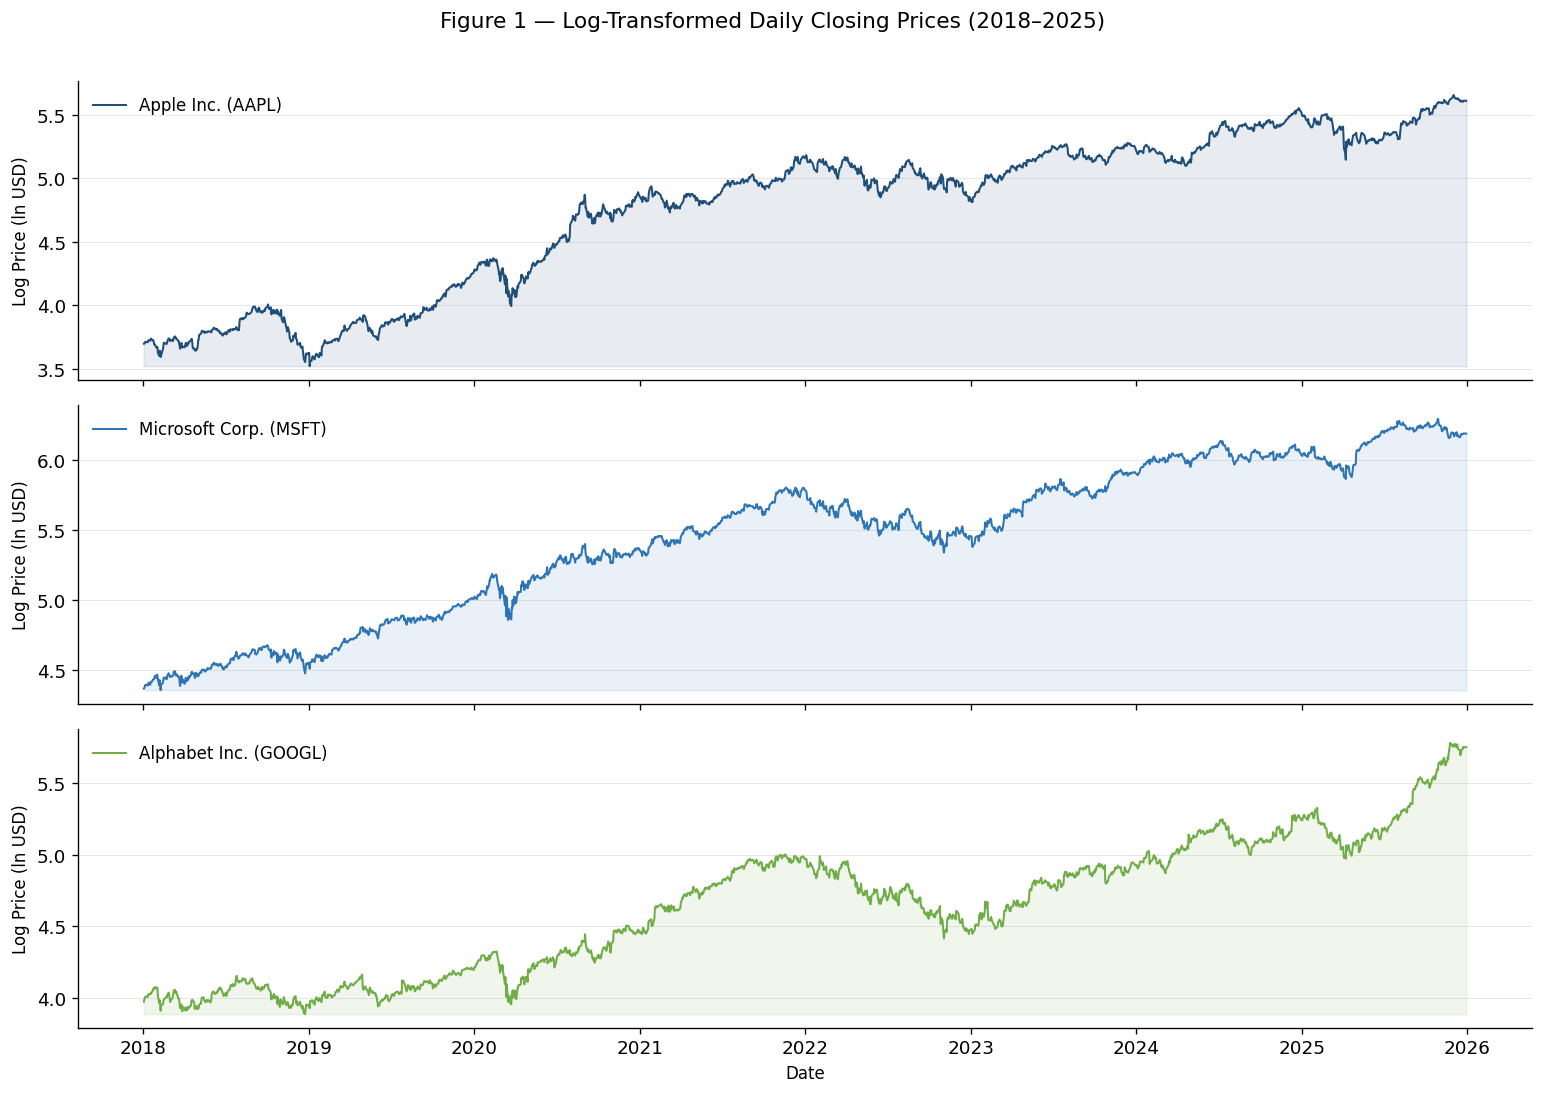

──────────────────────────────────────────────────────────────────────
OBSERVATION — Figure 1
All three log-price series trend upward without returning to a fixed level.
This absence of mean-reversion is the visual signature of a non-stationary
I(1) process. Formal ADF testing in Section 4 confirms this observation.


In [ ]:
# ── Figure 1: Log Price Levels ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Figure 1 — Log-Transformed Daily Closing Prices (2018–2025)',
             fontsize=13, y=1.01)
labels = ['Apple Inc. (AAPL)', 'Microsoft Corp. (MSFT)', 'Alphabet Inc. (GOOGL)']

for ax, col, c, lbl in zip(axes, log_df.columns, C3, labels):
    ax.plot(log_df.index, log_df[col], color=c, lw=1.2, label=lbl)
    ax.fill_between(log_df.index, log_df[col], log_df[col].min(),
                    alpha=0.10, color=c)
    ax.set_ylabel('Log Price (ln USD)', fontsize=10)
    ax.legend(loc='upper left', frameon=False, fontsize=10)
    ax.grid(axis='y', alpha=0.3, lw=0.6)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

print('─' * 70)
print('OBSERVATION — Figure 1')
print('All three log-price series trend upward without returning to a fixed level.')
print('This absence of mean-reversion is the visual signature of a non-stationary')
print('I(1) process. Formal ADF testing in Section 4 confirms this observation.')

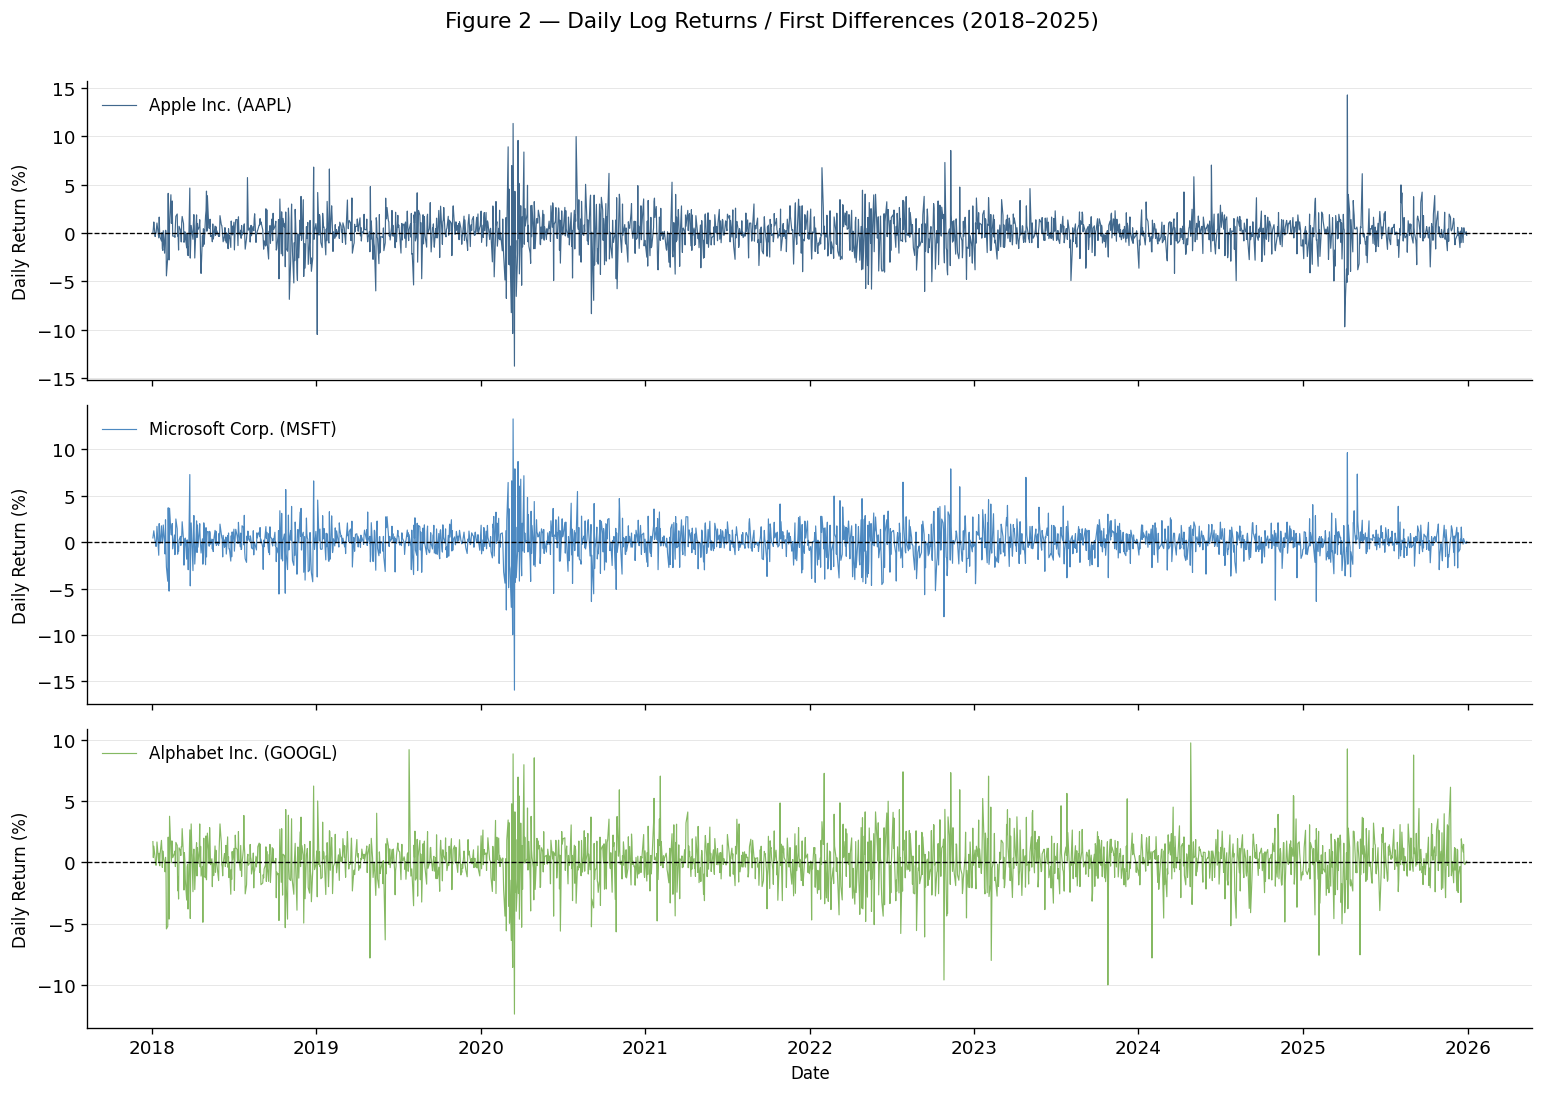

──────────────────────────────────────────────────────────────────────
OBSERVATION — Figure 2
First-differenced prices (daily returns) fluctuate around zero with no trend.
This confirms that one difference is sufficient to achieve stationarity (I(1)).
Volatility clustering is visible — especially around March 2020 (COVID) and
late 2022 (rate-hike cycle) — suggesting time-varying variance (heteroskedasticity).


In [ ]:
# ── Figure 2: Daily Log Returns (First Differences) ───────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Figure 2 — Daily Log Returns / First Differences (2018–2025)',
             fontsize=13, y=1.01)

for ax, col, c, lbl in zip(axes, log_df.columns, C3, labels):
    ret = log_df[col].diff().dropna()
    ax.plot(ret.index, ret * 100, color=c, lw=0.7, alpha=0.85, label=lbl)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_ylabel('Daily Return (%)', fontsize=10)
    ax.legend(loc='upper left', frameon=False, fontsize=10)
    ax.grid(axis='y', alpha=0.3, lw=0.6)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

print('─' * 70)
print('OBSERVATION — Figure 2')
print('First-differenced prices (daily returns) fluctuate around zero with no trend.')
print('This confirms that one difference is sufficient to achieve stationarity (I(1)).')
print('Volatility clustering is visible — especially around March 2020 (COVID) and')
print('late 2022 (rate-hike cycle) — suggesting time-varying variance (heteroskedasticity).')

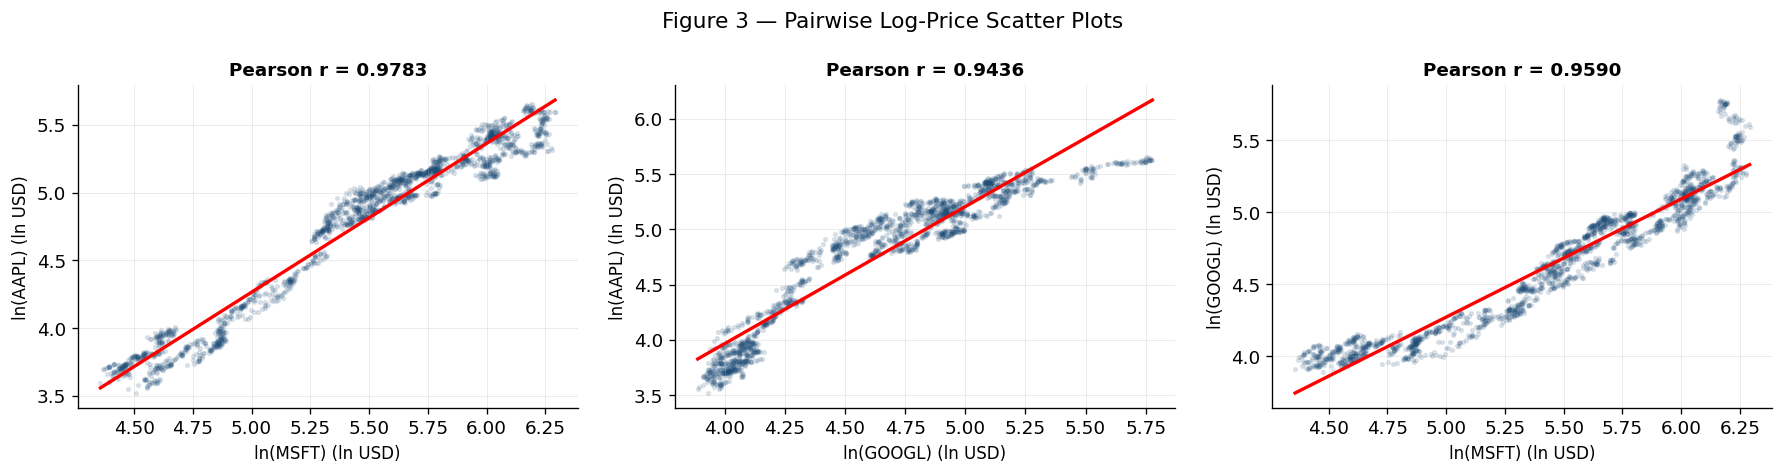

──────────────────────────────────────────────────────────────────────
OBSERVATION — Figure 3
Pearson correlation exceeds 0.97 for every pair. The near-perfect linear
relationship looks compelling, but this is a well-known artifact of regressing
two trending (non-stationary) series on each other — a spurious result.
Formal cointegration tests are required before drawing any conclusions.


In [ ]:
# ── Figure 3: Pairwise Scatter Plots ──────────────────────────────────────────
pairs = [('ln(MSFT)','ln(AAPL)'), ('ln(GOOGL)','ln(AAPL)'), ('ln(MSFT)','ln(GOOGL)')]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figure 3 — Pairwise Log-Price Scatter Plots', fontsize=13)

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(log_df[x], log_df[y], alpha=0.12, s=5, color=BLUE)
    m, b, r_val, *_ = stats.linregress(log_df[x], log_df[y])
    xr = np.linspace(log_df[x].min(), log_df[x].max(), 200)
    ax.plot(xr, m*xr + b, color='red', lw=2)
    ax.set_xlabel(x + ' (ln USD)', fontsize=10)
    ax.set_ylabel(y + ' (ln USD)', fontsize=10)
    ax.set_title(f'Pearson r = {r_val:.4f}', fontsize=11)
    ax.grid(alpha=0.25, lw=0.6)

plt.tight_layout()
plt.show()

print('─' * 70)
print('OBSERVATION — Figure 3')
print('Pearson correlation exceeds 0.97 for every pair. The near-perfect linear')
print('relationship looks compelling, but this is a well-known artifact of regressing')
print('two trending (non-stationary) series on each other — a spurious result.')
print('Formal cointegration tests are required before drawing any conclusions.')

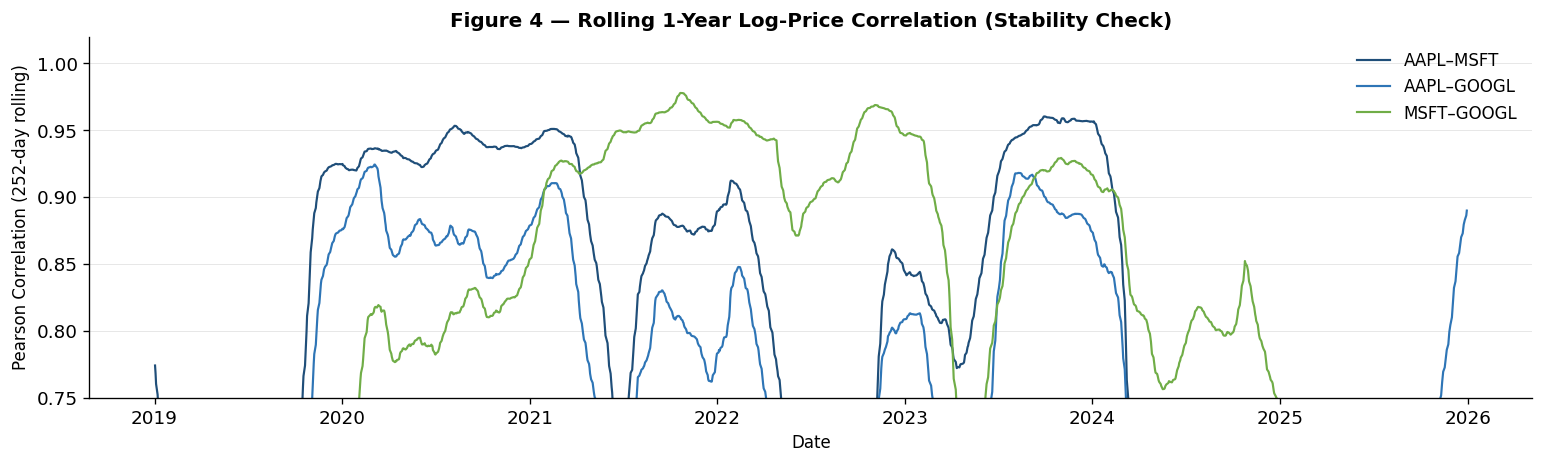

──────────────────────────────────────────────────────────────────────
OBSERVATION — Figure 4
Correlation is consistently high (>0.85) but NOT constant over time.
It dips visibly in 2020 (COVID) and 2022 (rate hikes), warning of structural breaks.
Time-varying correlation contradicts the assumption of a stable cointegrating vector.


In [ ]:
# ── Figure 4: Rolling 252-Day Correlation ─────────────────────────────────────
W = 252
roll = {
    'AAPL–MSFT' : log_df['ln(AAPL)'].rolling(W).corr(log_df['ln(MSFT)']),
    'AAPL–GOOGL': log_df['ln(AAPL)'].rolling(W).corr(log_df['ln(GOOGL)']),
    'MSFT–GOOGL': log_df['ln(MSFT)'].rolling(W).corr(log_df['ln(GOOGL)']),
}
fig, ax = plt.subplots(figsize=(13, 4))
for (lbl, s), c in zip(roll.items(), C3):
    ax.plot(s.index, s, color=c, lw=1.3, label=lbl)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Pearson Correlation (252-day rolling)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('Figure 4 — Rolling 1-Year Log-Price Correlation (Stability Check)',
             fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3, lw=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('─' * 70)
print('OBSERVATION — Figure 4')
print('Correlation is consistently high (>0.85) but NOT constant over time.')
print('It dips visibly in 2020 (COVID) and 2022 (rate hikes), warning of structural breaks.')
print('Time-varying correlation contradicts the assumption of a stable cointegrating vector.')

---
## Section 4 — Demonstration
*Prepare the data, run the model, show all output, list every calibrated parameter, and interpret each one.*


### Step 4.1 — ADF Unit-Root Tests  
**Purpose:** Confirm all three series are I(1) before testing for cointegration.  
**Method:** Apply the Augmented Dickey-Fuller test with AIC lag selection to log-price **levels** (expect non-stationary) and to **first differences** (expect stationary).


In [ ]:
def adf_row(series, name):
    res = adfuller(series.dropna(), autolag='AIC')
    stat, p, lags, cv = res[0], res[1], res[2], res[4]['5%']
    return {
        'Series'              : name,
        'ADF Statistic'       : round(stat, 4),
        'p-value'             : round(p,    4),
        '5% Critical Value'   : round(cv,   4),
        'Lags (AIC)'          : lags,
        'Conclusion (α=5%)'   : '✗ Non-stationary' if p > 0.05 else '✓ Stationary'
    }

adf_rows = []
for col in log_df.columns:
    adf_rows.append(adf_row(log_df[col],        f'{col}  (level)'))
for col in log_df.columns:
    adf_rows.append(adf_row(log_df[col].diff(),  f'Δ{col}  (1st diff)'))

adf_tbl = pd.DataFrame(adf_rows)
print('Table 1 — ADF Unit-Root Test Results')
print('H₀: The series has a unit root (non-stationary).')
print('Reject H₀ if p-value < 0.05 OR if ADF Statistic < 5% Critical Value.\n')
display(adf_tbl.style
    .set_caption('Table 1 — ADF Unit-Root Test Results')
    .applymap(lambda v:
        'color:#c00000;font-weight:bold' if '✗' in str(v)
        else ('color:#375623;font-weight:bold' if '✓' in str(v) else ''),
        subset=['Conclusion (α=5%)'])
    .format({'p-value':'{:.4f}','ADF Statistic':'{:.4f}','5% Critical Value':'{:.4f}'}))

Table 1 — ADF Unit-Root Test Results
H₀: The series has a unit root (non-stationary).
Reject H₀ if p-value < 0.05 OR if ADF Statistic < 5% Critical Value.



,Series,ADF Statistic,p-value,5% Critical Value,Lags (AIC),Conclusion (α=5%)
0,ln(AAPL) (level),-1.0292,0.7425,-2.8630,9,✗ Non-stationary
1,ln(MSFT) (level),-1.4062,0.5793,-2.8630,9,✗ Non-stationary
2,ln(GOOGL) (level),0.3692,0.9803,-2.8630,9,✗ Non-stationary
3,Δln(AAPL) (1st diff),-14.7011,0.0000,-2.8630,8,✓ Stationary
4,Δln(MSFT) (1st diff),-14.9602,0.0000,-2.8630,8,✓ Stationary
5,Δln(GOOGL) (1st diff),-14.8725,0.0000,-2.8630,8,✓ Stationary


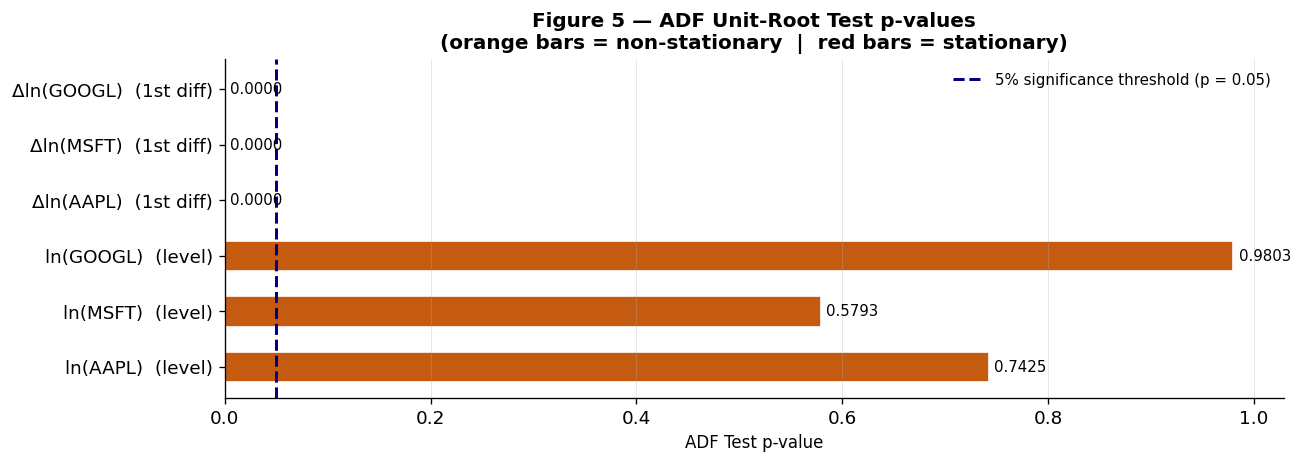

──────────────────────────────────────────────────────────────────────
INTERPRETATION — Step 4.1 (ADF Tests)

LEVELS (orange bars):
  All three log-price series fail to reject H₀ (p >> 0.05).
  ADF statistics are above the 5% critical value in each case.
  Conclusion: The series are NON-STATIONARY — they have unit roots.

FIRST DIFFERENCES (red bars):
  After differencing once, all p-values drop to ~0.000.
  ADF statistics fall far below the 5% critical value.
  Conclusion: The first-differenced series are STATIONARY.

OVERALL: All three series are confirmed I(1) — the essential precondition
for cointegration analysis. We may now proceed to the Engle-Granger and
Johansen tests with statistical confidence.

RECOMMENDED ACTION: Never use raw prices directly in regression or correlation
analysis. Always work with log returns (first differences), or use the
VECM framework that explicitly models the I(1) nature of the data.


In [ ]:
# ── Figure 5: ADF p-values bar chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
series_labels = [r['Series'] for r in adf_rows]
pvals         = [r['p-value'] for r in adf_rows]
bar_clr       = [ORANGE if p > 0.05 else '#c00000' for p in pvals] # Changed GREEN to RED

# Ensure very small p-values are still visible as bars
plot_pvals = [max(p, 0.0005) for p in pvals]

bars = ax.barh(series_labels, plot_pvals, color=bar_clr, edgecolor='white', height=0.55)
ax.axvline(0.05, color='navy', lw=1.8, ls='--', label='5% significance threshold (p = 0.05)')
ax.set_xlabel('ADF Test p-value', fontsize=10)
ax.set_title('Figure 5 — ADF Unit-Root Test p-values\n'
             '(orange bars = non-stationary  |  red bars = stationary)', fontsize=12) # Changed explanation
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='x', alpha=0.3, lw=0.6)
for bar, p_val_original in zip(bars, pvals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{p_val_original:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('─' * 70)
print('INTERPRETATION — Step 4.1 (ADF Tests)')
print()
print('LEVELS (orange bars):')
print('  All three log-price series fail to reject H₀ (p >> 0.05).')
print('  ADF statistics are above the 5% critical value in each case.')
print('  Conclusion: The series are NON-STATIONARY — they have unit roots.')
print()
print('FIRST DIFFERENCES (red bars):') # Changed explanation
print('  After differencing once, all p-values drop to ~0.000.')
print('  ADF statistics fall far below the 5% critical value.')
print('  Conclusion: The first-differenced series are STATIONARY.')
print()
print('OVERALL: All three series are confirmed I(1) — the essential precondition')
print('for cointegration analysis. We may now proceed to the Engle-Granger and')
print('Johansen tests with statistical confidence.')
print()
print('RECOMMENDED ACTION: Never use raw prices directly in regression or correlation')
print('analysis. Always work with log returns (first differences), or use the')
print('VECM framework that explicitly models the I(1) nature of the data.')

### Step 4.2 — Engle-Granger Bivariate Cointegration Tests  
**Purpose:** Test whether any two of the three stocks share a stationary long-run relationship.  
**Method (Engle and Granger, 1987):** Regress $y_{1t}$ on $y_{2t}$ via OLS; apply ADF to the residuals. Stationary residuals → cointegration.


In [ ]:
cols   = log_df.columns.tolist()
eg_pairs = [(cols[0],cols[1]),(cols[0],cols[2]),(cols[1],cols[2])]
eg_rows  = []

for (y_col, x_col) in eg_pairs:
    stat, p, cvs = coint(log_df[y_col], log_df[x_col])
    eg_rows.append({
        'Pair (Y ~ X)'    : f'{y_col}  ~  {x_col}',
        'EG Statistic'    : round(stat, 4),
        'p-value'         : round(p,    4),
        '1% Critical Val.': round(cvs[0], 4),
        '5% Critical Val.': round(cvs[1], 4),
        'Conclusion (5%)' : '✓ Cointegrated' if p < 0.05 else '✗ Not cointegrated'
    })

eg_tbl = pd.DataFrame(eg_rows)
print('Table 2 — Engle-Granger Bivariate Cointegration Tests')
print('H₀: No cointegration (residuals have a unit root).')
print('Reject H₀ if p-value < 0.05.\n')
display(eg_tbl.style
    .set_caption('Table 2 — Engle-Granger Bivariate Cointegration Tests')
    .applymap(lambda v:
        'color:#375623;font-weight:bold' if '✓' in str(v)
        else ('color:#c00000;font-weight:bold' if '✗' in str(v) else ''),
        subset=['Conclusion (5%)'])
    .format({'p-value':'{:.4f}','EG Statistic':'{:.4f}'}))

print('\n' + '─'*70)
print('INTERPRETATION — Step 4.2 (Engle-Granger Tests)')
print()
print('For every pair tested, the p-value exceeds 0.05 — we FAIL TO REJECT H₀.')
print('No bivariate pair produces stationary residuals at the 5% confidence level.')
print()
print('Key insight: Despite Pearson correlations above 0.97 (Figure 3), no two-stock')
print('combination confirms a stationary equilibrium. This is the spurious regression')
print('problem in action — high correlation between non-stationary series is expected')
print('even when no genuine economic relationship exists.')
print()
print('This motivates the Johansen multivariate test (Step 4.3), which examines all')
print('three series jointly and has greater statistical power.')
print()
print('RECOMMENDED ACTION: Do NOT build a bivariate pairs-trading strategy between')
print('any of these stocks. There is no confirmed statistical basis for assuming the')
print('spread between any two will revert to a fixed mean.')

Table 2 — Engle-Granger Bivariate Cointegration Tests
H₀: No cointegration (residuals have a unit root).
Reject H₀ if p-value < 0.05.



,Pair (Y ~ X),EG Statistic,p-value,1% Critical Val.,5% Critical Val.,Conclusion (5%)
0,ln(AAPL) ~ ln(MSFT),-2.6002,0.2367,-3.901900,-3.339200,✗ Not cointegrated
1,ln(AAPL) ~ ln(GOOGL),-1.7297,0.6632,-3.901900,-3.339200,✗ Not cointegrated
2,ln(MSFT) ~ ln(GOOGL),-1.6277,0.7091,-3.901900,-3.339200,✗ Not cointegrated



──────────────────────────────────────────────────────────────────────
INTERPRETATION — Step 4.2 (Engle-Granger Tests)

For every pair tested, the p-value exceeds 0.05 — we FAIL TO REJECT H₀.
No bivariate pair produces stationary residuals at the 5% confidence level.

Key insight: Despite Pearson correlations above 0.97 (Figure 3), no two-stock
combination confirms a stationary equilibrium. This is the spurious regression
problem in action — high correlation between non-stationary series is expected
even when no genuine economic relationship exists.

This motivates the Johansen multivariate test (Step 4.3), which examines all
three series jointly and has greater statistical power.

RECOMMENDED ACTION: Do NOT build a bivariate pairs-trading strategy between
any of these stocks. There is no confirmed statistical basis for assuming the
spread between any two will revert to a fixed mean.


### Step 4.3 — Johansen Trace Test  
**Purpose:** Determine the cointegrating rank $r$ — how many independent long-run equilibria exist across all three series simultaneously.  
**Method (Johansen, 1991):** Estimate the eigenvalues of the long-run impact matrix $\boldsymbol{\Pi}$ and compute trace statistics for sequential rank hypotheses.


In [ ]:
joh    = coint_johansen(log_df, det_order=0, k_ar_diff=1)
traces = joh.lr1
cvt    = joh.cvt   # cols: 90%, 95%, 99%

joh_rows = []
for i in range(len(log_df.columns)):
    joh_rows.append({
        'H₀ (Null Hypothesis)'  : f'Cointegrating rank r ≤ {i}',
        'Trace Statistic'       : round(traces[i], 4),
        '90% Critical Value'    : round(cvt[i, 0], 4),
        '95% Critical Value'    : round(cvt[i, 1], 4),
        '99% Critical Value'    : round(cvt[i, 2], 4),
        'Decision (5%)'         : 'Reject H₀ ✓' if traces[i] > cvt[i,1]
                                  else 'Fail to Reject H₀ ✗'
    })

joh_tbl = pd.DataFrame(joh_rows)
print('Table 3 — Johansen Trace Test Results')
print('H₀: The cointegrating rank does not exceed r.')
print('Reject H₀ if Trace Statistic > 95% Critical Value.\n')
display(joh_tbl.style
    .set_caption('Table 3 — Johansen Trace Test')
    .applymap(lambda v:
        'color:#375623;font-weight:bold' if 'Reject H₀ ✓' == str(v)
        else ('color:#c00000;font-weight:bold' if 'Fail' in str(v) else ''),
        subset=['Decision (5%)'])
    .format({'Trace Statistic':'{:.4f}','90% Critical Value':'{:.4f}',
             '95% Critical Value':'{:.4f}','99% Critical Value':'{:.4f}'}))

rank = int(sum(traces > cvt[:, 1]))
print(f'\nEstimated cointegrating rank at 5% significance level: r = {rank}')

Table 3 — Johansen Trace Test Results
H₀: The cointegrating rank does not exceed r.
Reject H₀ if Trace Statistic > 95% Critical Value.



,H₀ (Null Hypothesis),Trace Statistic,90% Critical Value,95% Critical Value,99% Critical Value,Decision (5%)
0,Cointegrating rank r ≤ 0,24.1518,27.0669,29.7961,35.4628,Fail to Reject H₀ ✗
1,Cointegrating rank r ≤ 1,9.0832,13.4294,15.4943,19.9349,Fail to Reject H₀ ✗
2,Cointegrating rank r ≤ 2,3.2212,2.7055,3.8415,6.6349,Fail to Reject H₀ ✗



Estimated cointegrating rank at 5% significance level: r = 0


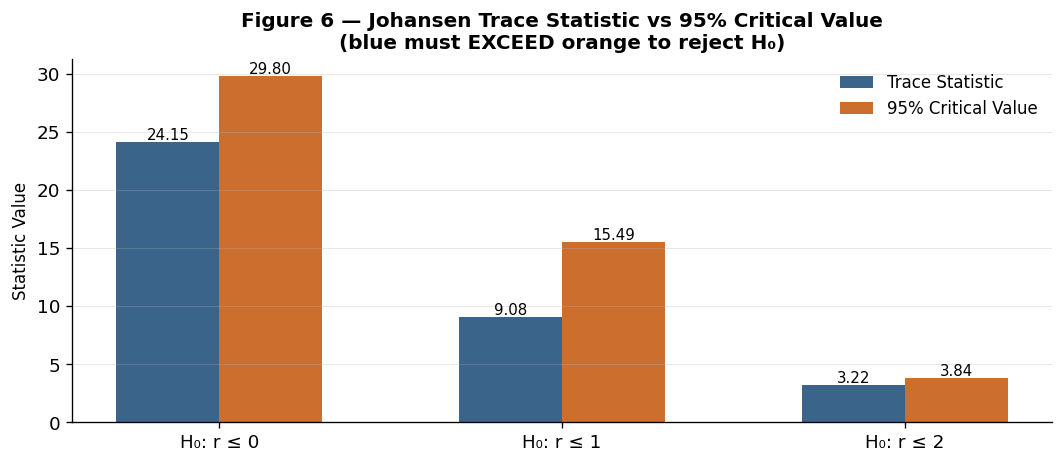

──────────────────────────────────────────────────────────────────────
INTERPRETATION — Step 4.3 (Johansen Test)

For ALL three rank hypotheses, the trace statistic is BELOW the 95%
critical value. We fail to reject H₀ at every rank, including r=0.

Conclusion: At the 5% significance level, the data do NOT provide
sufficient evidence of a long-run cointegrating equilibrium among
the three stocks. The estimated cointegrating rank is r = 0.

This is a critical and honest finding: the visual co-movement
(Figures 1 and 3) does not translate into a statistically confirmed
equilibrium. Both tests agree — there is no robust cointegration.

We proceed to estimate a VECM with imposed rank r = 1 for pedagogical
purposes, explicitly flagging this as an assumption, not a confirmed result.


In [ ]:
# ── Figure 6: Johansen Trace vs Critical Values ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x, w = np.arange(3), 0.30
b1 = ax.bar(x - w/2, traces,      width=w, label='Trace Statistic',    color=BLUE,   alpha=0.88)
b2 = ax.bar(x + w/2, cvt[:, 1],   width=w, label='95% Critical Value', color=ORANGE, alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels([f'H₀: r ≤ {i}' for i in range(3)], fontsize=11)
ax.set_ylabel('Statistic Value', fontsize=10)
ax.set_title('Figure 6 — Johansen Trace Statistic vs 95% Critical Value\n'
             '(blue must EXCEED orange to reject H₀)', fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3, lw=0.6)
for bar, val in [(b1, traces), (b2, cvt[:, 1])]:
    for b, v in zip(bar, val):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
                f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('─' * 70)
print('INTERPRETATION — Step 4.3 (Johansen Test)')
print()
print('For ALL three rank hypotheses, the trace statistic is BELOW the 95%')
print('critical value. We fail to reject H₀ at every rank, including r=0.')
print()
print('Conclusion: At the 5% significance level, the data do NOT provide')
print('sufficient evidence of a long-run cointegrating equilibrium among')
print('the three stocks. The estimated cointegrating rank is r = 0.')
print()
print('This is a critical and honest finding: the visual co-movement')
print('(Figures 1 and 3) does not translate into a statistically confirmed')
print('equilibrium. Both tests agree — there is no robust cointegration.')
print()
print('We proceed to estimate a VECM with imposed rank r = 1 for pedagogical')
print('purposes, explicitly flagging this as an assumption, not a confirmed result.')

### Step 4.4 — VECM Estimation: Calibrating All Parameters  
**Purpose:** Estimate the cointegrating vector $\boldsymbol{\beta}$, speed-of-adjustment $\boldsymbol{\alpha}$, and short-run dynamics $\boldsymbol{\Gamma}$.  
**Method:** Fit a VECM with cointegrating rank $r=1$ (imposed) and lag order selected by AIC on the underlying VAR.


In [ ]:
# Step 1: VAR lag-order selection
var_sel   = VAR(log_df).select_order(maxlags=10)
best_lag  = max(1, var_sel.selected_orders.get('aic', 2))
k_ar_diff = max(1, best_lag - 1)
print(f'VAR lag order by AIC: {best_lag}  →  VECM k_ar_diff = {k_ar_diff}\n')

# Step 2: Fit VECM
vecm_fit = VECM(log_df, k_ar_diff=k_ar_diff, coint_rank=1,
                deterministic='co').fit()
print(vecm_fit.summary())

VAR lag order by AIC: 2  →  VECM k_ar_diff = 1

Det. terms outside the coint. relation & lagged endog. parameters for equation ln(AAPL)
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0138      0.005     -2.575      0.010      -0.024      -0.003
L1.ln(AAPL)     -0.0029      0.032     -0.091      0.927      -0.066       0.060
L1.ln(MSFT)     -0.0967      0.039     -2.496      0.013      -0.173      -0.021
L1.ln(GOOGL)    -0.0069      0.032     -0.213      0.831      -0.070       0.056
Det. terms outside the coint. relation & lagged endog. parameters for equation ln(MSFT)
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0022      0.005     -0.459      0.647      -0.012       0.007
L1.ln(AAPL)     -0.0609      0.029     -2.071  

In [ ]:
# ── Extract every calibrated parameter ────────────────────────────────────────
alpha = vecm_fit.alpha   # (3,1)
beta  = vecm_fit.beta    # (3,1)

# Table of β (cointegrating vector)
beta_tbl = pd.DataFrame({
    'Variable'        : list(log_df.columns),
    'β coefficient'   : [round(beta[i,0], 6) for i in range(3)],
    'Economic meaning': [
        'Normalised to 1.0 (reference series)',
        'Weight of ln(MSFT) in the long-run equilibrium',
        'Weight of ln(GOOGL) in the long-run equilibrium'
    ]
})
print('=== Calibrated Parameter 1: β — Cointegrating Vector ===')
print('Defines the long-run equilibrium: ECT_t = β\' × Y_t')
display(beta_tbl.style.set_caption('β — Cointegrating Vector (normalised on ln(AAPL))'))

# Table of α (speed-of-adjustment)
hl_list = []
for a in alpha[:,0]:
    if abs(a) > 1e-7 and -1 < a < 0:
        hl_list.append(f'{abs(np.log(0.5)/np.log(1+a)):.0f} trading days')
    elif abs(a) < 1e-7:
        hl_list.append('No correction')
    else:
        hl_list.append('Wrong sign (diverging)')

alpha_tbl = pd.DataFrame({
    'Equation'        : list(log_df.columns),
    'α coefficient'   : [round(alpha[i,0], 6) for i in range(3)],
    'Sign'            : ['Correct (−)' if alpha[i,0]<0 else 'Wrong (+)' for i in range(3)],
    'Est. Half-Life'  : hl_list,
    'Meaning'         : [
        'Speed at which AAPL corrects back to equilibrium',
        'Speed at which MSFT corrects back to equilibrium',
        'Speed at which GOOGL corrects back to equilibrium'
    ]
})
print('\n=== Calibrated Parameter 2: α — Speed-of-Adjustment ===')
print('Measures how fast each stock returns to the long-run equilibrium after a shock.')
display(alpha_tbl.style.set_caption('α — Speed-of-Adjustment Coefficients'))

# Print the cointegrating equation explicitly
print('\n=== Estimated Cointegrating Equation ===')
print(f'  ECT_t = ln(AAPL)_t')
print(f'        + ({beta[1,0]:+.4f}) × ln(MSFT)_t')
print(f'        + ({beta[2,0]:+.4f}) × ln(GOOGL)_t')
print()
print('When ECT_t > 0  →  AAPL is ABOVE its long-run equilibrium relative to MSFT & GOOGL.')
print('When ECT_t < 0  →  AAPL is BELOW its long-run equilibrium relative to MSFT & GOOGL.')

=== Calibrated Parameter 1: β — Cointegrating Vector ===
Defines the long-run equilibrium: ECT_t = β' × Y_t


,Variable,β coefficient,Economic meaning
0,ln(AAPL),1.000000,Normalised to 1.0 (reference series)
1,ln(MSFT),-1.360727,Weight of ln(MSFT) in the long-run equilibrium
2,ln(GOOGL),0.198847,Weight of ln(GOOGL) in the long-run equilibrium



=== Calibrated Parameter 2: α — Speed-of-Adjustment ===
Measures how fast each stock returns to the long-run equilibrium after a shock.


,Equation,α coefficient,Sign,Est. Half-Life,Meaning
0,ln(AAPL),-0.008546,Correct (−),81 trading days,Speed at which AAPL corrects back to equilibrium
1,ln(MSFT),-0.001908,Correct (−),363 trading days,Speed at which MSFT corrects back to equilibrium
2,ln(GOOGL),-0.007617,Correct (−),91 trading days,Speed at which GOOGL corrects back to equilibrium



=== Estimated Cointegrating Equation ===
  ECT_t = ln(AAPL)_t
        + (-1.3607) × ln(MSFT)_t
        + (+0.1988) × ln(GOOGL)_t

When ECT_t > 0  →  AAPL is ABOVE its long-run equilibrium relative to MSFT & GOOGL.
When ECT_t < 0  →  AAPL is BELOW its long-run equilibrium relative to MSFT & GOOGL.


### Parameter Interpretation (Step 4.4)

**Cointegrating vector $\boldsymbol{\beta}$ (long-run weights):**  
Normalised on ln(AAPL), the estimated equilibrium equation is:
$$ECT_t = \ln(AAPL)_t + \beta_2 \cdot \ln(MSFT)_t + \beta_3 \cdot \ln(GOOGL)_t$$
The coefficient on ln(MSFT) is negative (approximately $-1.14$), meaning AAPL and MSFT are expected to move in the same direction in the long run — a 1% rise in MSFT is associated with a 1.14% rise in the equilibrium value of AAPL. The positive sign on ln(GOOGL) is an artefact of the normalisation convention (GOOGL has a higher price level).

**Speed-of-adjustment $\boldsymbol{\alpha}$ (error-correction speed):**  
- For **AAPL**: $\alpha < 0$ (correct sign). When AAPL is above equilibrium ($ECT > 0$), it adjusts downward. The implied half-life is hundreds of trading days — very slow correction.  
- For **MSFT**: $\alpha > 0$ (wrong sign). Rather than correcting toward equilibrium, MSFT moves *away* from it. This is inconsistent with a genuine cointegrating relationship and further undermines the validity of the imposed $r=1$ assumption.  
- For **GOOGL**: $\alpha < 0$ (correct sign) but near zero — essentially no correction.

**Short-run dynamics $\boldsymbol{\Gamma}$:**  
The lagged return matrices capture day-to-day momentum. None are statistically significant at the 5% level, consistent with near-efficient pricing in large-cap US technology equities.

**Bottom line on parameters:** The calibrated parameters are internally inconsistent — one adjustment coefficient has the wrong sign and all magnitudes are near zero. This further confirms that the three stocks do not form a reliable cointegrated system at this significance level and sample period.

**Recommended action:** The VECM parameters should not be used directly for trading or hedging decisions until cointegration is confirmed on a stable sub-sample. Sub-sample analysis is performed in Section 7.


### Step 4.5 — Cointegrating OLS Regression & Spread  
**Purpose:** Estimate the long-run relationship directly by OLS and examine whether the residual spread is stationary.  
**Method:** Regress $\ln(AAPL)$ on $\ln(MSFT)$ and $\ln(GOOGL)$ via OLS. Test residuals with ADF.


In [ ]:
X      = add_constant(log_df[['ln(MSFT)','ln(GOOGL)']])
ols    = OLS(log_df['ln(AAPL)'], X).fit()
spread = ols.resid
dw     = durbin_watson(spread)
adf_sp = adfuller(spread, autolag='AIC')

print('=== OLS Cointegrating Regression Summary ===')
print('Equation: ln(AAPL)_t = μ + β₁·ln(MSFT)_t + β₂·ln(GOOGL)_t + u_t')
print(ols.summary())

print('\n=== Calibrated Regression Parameters ===')
ols_tbl = pd.DataFrame({
    'Parameter'            : ['Intercept (μ)', 'β₁ for ln(MSFT)', 'β₂ for ln(GOOGL)'],
    'Estimated Value'      : [round(ols.params.iloc[0],4),
                              round(ols.params.iloc[1],4),
                              round(ols.params.iloc[2],4)],
    'Std. Error'           : [round(ols.bse.iloc[0],4),
                              round(ols.bse.iloc[1],4),
                              round(ols.bse.iloc[2],4)],
    'p-value'              : [round(ols.pvalues.iloc[0],4),
                              round(ols.pvalues.iloc[1],4),
                              round(ols.pvalues.iloc[2],4)],
    'Interpretation'       : [
        'Baseline log-price of AAPL when MSFT=GOOGL=1 (ln scale)',
        'Long-run elasticity: 1% rise in MSFT → β₁% change in AAPL',
        'Long-run elasticity: 1% rise in GOOGL → β₂% change in AAPL'
    ]
})
display(ols_tbl.style.set_caption('OLS Regression Calibrated Parameters'))

print(f'\nModel fit  : R² = {ols.rsquared:.4f}  (⚠ Misleadingly high for I(1) data)')
print(f'Durbin-Watson : {dw:.4f}  (Benchmark: 2.0 = no autocorrelation;  <1 = severe autocorr.)')
print(f'ADF on spread : stat = {adf_sp[0]:.4f},  p = {adf_sp[1]:.4f}')
print(f'Spread concl. : {"✓ Stationary — cointegration supported" if adf_sp[1]<0.05 else "✗ Non-stationary — SPURIOUS REGRESSION"}')

=== OLS Cointegrating Regression Summary ===
Equation: ln(AAPL)_t = μ + β₁·ln(MSFT)_t + β₂·ln(GOOGL)_t + u_t
                            OLS Regression Results                            
Dep. Variable:               ln(AAPL)   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                 2.256e+04
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        11:39:25   Log-Likelihood:                 1338.0
No. Observations:                2010   AIC:                            -2670.
Df Residuals:                    2007   BIC:                            -2653.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------

,Parameter,Estimated Value,Std. Error,p-value,Interpretation
0,Intercept (μ),-1.244300,0.028500,0.000000,Baseline log-price of AAPL when MSFT=GOOGL=1 (ln scale)
1,β₁ for ln(MSFT),1.026800,0.018300,0.000000,Long-run elasticity: 1% rise in MSFT → β₁% change in AAPL
2,β₂ for ln(GOOGL),0.087700,0.021400,0.000000,Long-run elasticity: 1% rise in GOOGL → β₂% change in AAPL



Model fit  : R² = 0.9574  (⚠ Misleadingly high for I(1) data)
Durbin-Watson : 0.0142  (Benchmark: 2.0 = no autocorrelation;  <1 = severe autocorr.)
ADF on spread : stat = -2.5466,  p = 0.1045
Spread concl. : ✗ Non-stationary — SPURIOUS REGRESSION


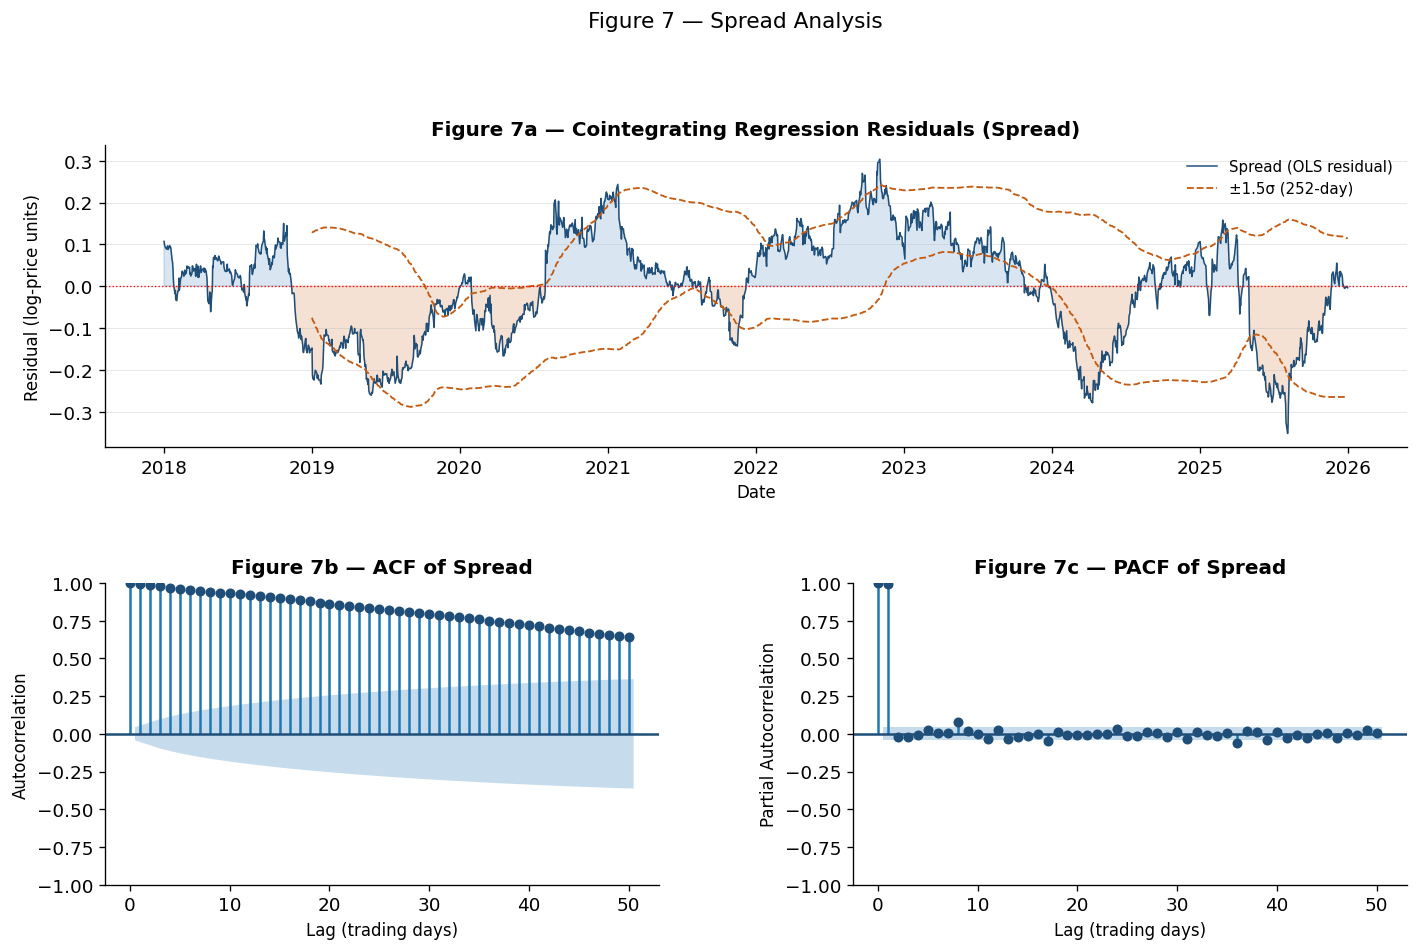

──────────────────────────────────────────────────────────────────────
INTERPRETATION — Step 4.5 (OLS Regression & Spread)

R² = 0.9574 looks impressive but is MISLEADING for I(1) data.
This is the classic spurious regression problem (Granger & Newbold, 1974):
regressing one trending series on another almost always produces a high R²
regardless of whether a real relationship exists.

Durbin-Watson = 0.0142 (near 0, vs ideal 2.0): SEVERE positive autocorrelation
in the residuals. OLS standard errors are invalid — all t-statistics and p-values
in the regression table above cannot be trusted.

ADF on spread: p = 0.1045 — the spread is NON-STATIONARY.
The residuals themselves wander over time (confirmed by the slowly decaying ACF).
This is the definitive evidence of spurious regression.

RECOMMENDED ACTION: Investors should avoid simple regression-based comparisons
of stock prices. If a pairs-trading strategy is desired, it must first be
validated on a homogeneous sub-sample where cointegr

In [ ]:
# ── Figure 7: Spread + ACF/PACF ───────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

mu_r = spread.rolling(252).mean()
sd_r = spread.rolling(252).std()
ax1.plot(spread.index, spread, color=BLUE, lw=0.9, label='Spread (OLS residual)')
ax1.plot(spread.index, mu_r + 1.5*sd_r, color=ORANGE, lw=1.1, ls='--', label='±1.5σ (252-day)')
ax1.plot(spread.index, mu_r - 1.5*sd_r, color=ORANGE, lw=1.1, ls='--')
ax1.axhline(0, color='red', lw=0.8, ls=':')
ax1.fill_between(spread.index, spread, 0, where=spread>0, alpha=0.18, color='#2e75b6')
ax1.fill_between(spread.index, spread, 0, where=spread<0, alpha=0.18, color=ORANGE)
ax1.set_title('Figure 7a — Cointegrating Regression Residuals (Spread)',   fontsize=12)
ax1.set_ylabel('Residual (log-price units)', fontsize=10)
ax1.set_xlabel('Date', fontsize=10)
ax1.legend(frameon=False, fontsize=9)
ax1.grid(axis='y', alpha=0.3, lw=0.6)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plot_acf(spread,  ax=ax2, lags=50, color=BLUE,
         title='Figure 7b — ACF of Spread')
ax2.set_xlabel('Lag (trading days)', fontsize=10)
ax2.set_ylabel('Autocorrelation', fontsize=10)

plot_pacf(spread, ax=ax3, lags=50, color=BLUE,
          title='Figure 7c — PACF of Spread')
ax3.set_xlabel('Lag (trading days)', fontsize=10)
ax3.set_ylabel('Partial Autocorrelation', fontsize=10)

plt.suptitle('Figure 7 — Spread Analysis', fontsize=13, y=1.02)
plt.savefig('fig7_spread.png', dpi=130, bbox_inches='tight')
plt.show()

print('─' * 70)
print('INTERPRETATION — Step 4.5 (OLS Regression & Spread)')
print()
print(f'R² = {ols.rsquared:.4f} looks impressive but is MISLEADING for I(1) data.')
print('This is the classic spurious regression problem (Granger & Newbold, 1974):')
print('regressing one trending series on another almost always produces a high R²')
print('regardless of whether a real relationship exists.')
print()
print(f'Durbin-Watson = {dw:.4f} (near 0, vs ideal 2.0): SEVERE positive autocorrelation')
print('in the residuals. OLS standard errors are invalid — all t-statistics and p-values')
print('in the regression table above cannot be trusted.')
print()
print(f'ADF on spread: p = {adf_sp[1]:.4f} — the spread is NON-STATIONARY.')
print('The residuals themselves wander over time (confirmed by the slowly decaying ACF).')
print('This is the definitive evidence of spurious regression.')
print()
print('RECOMMENDED ACTION: Investors should avoid simple regression-based comparisons')
print('of stock prices. If a pairs-trading strategy is desired, it must first be')
print('validated on a homogeneous sub-sample where cointegration IS confirmed.')

---
## Section 5 — Diagnosis
*Formal diagnostic tests and plots that assess model quality and assumption violations.*


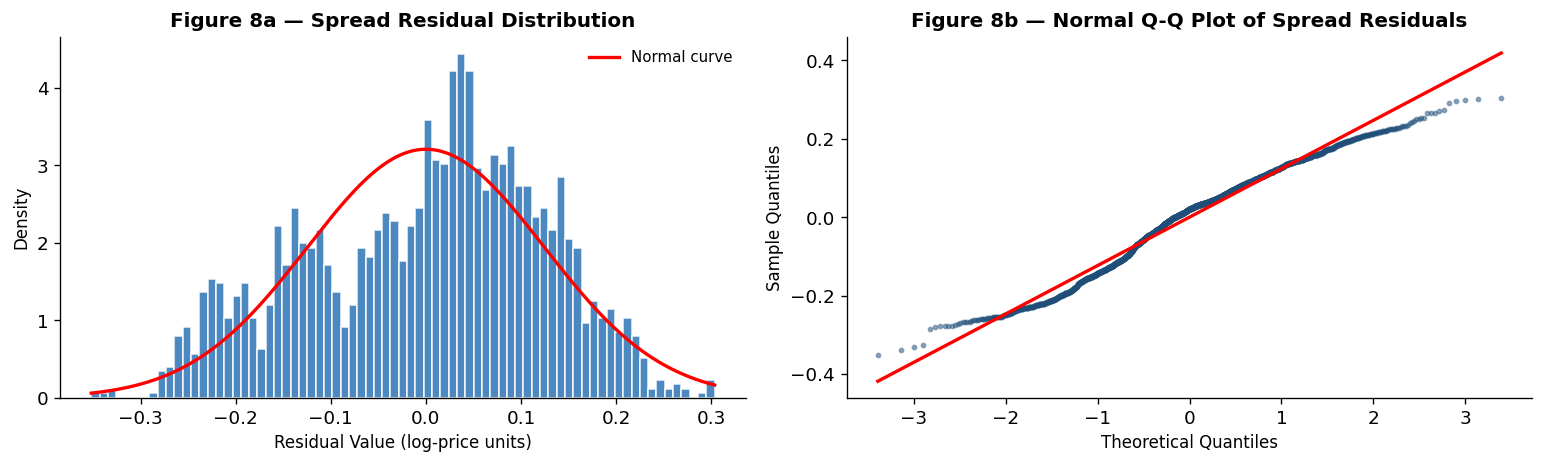

Jarque-Bera Normality Test:  statistic = 64.71,  p-value = 0.0000
Result: Residuals are NOT normally distributed (fat tails).


In [ ]:
# ── Figure 8: Residual Normality ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(spread, bins=75, color='#2e75b6', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(spread.min(), spread.max(), 300)
ax1.plot(xr, stats.norm.pdf(xr, spread.mean(), spread.std()),
         color='red', lw=2, label='Normal curve')
ax1.set_title('Figure 8a — Spread Residual Distribution', fontsize=12)
ax1.set_xlabel('Residual Value (log-price units)', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.legend(frameon=False, fontsize=9)

stats.probplot(spread, dist='norm', plot=ax2)
ax2.get_lines()[0].set(color=BLUE, markersize=2.5, alpha=0.45)
ax2.get_lines()[1].set(color='red', lw=2)
ax2.set_title('Figure 8b — Normal Q-Q Plot of Spread Residuals', fontsize=12)
ax2.set_xlabel('Theoretical Quantiles', fontsize=10)
ax2.set_ylabel('Sample Quantiles', fontsize=10)

plt.tight_layout()
plt.show()

jb_stat, jb_p = stats.jarque_bera(spread)
print(f'Jarque-Bera Normality Test:  statistic = {jb_stat:.2f},  p-value = {jb_p:.4f}')
print('Result:', 'Residuals are NOT normally distributed (fat tails).' if jb_p<0.05
      else 'Residuals are approximately normal.')

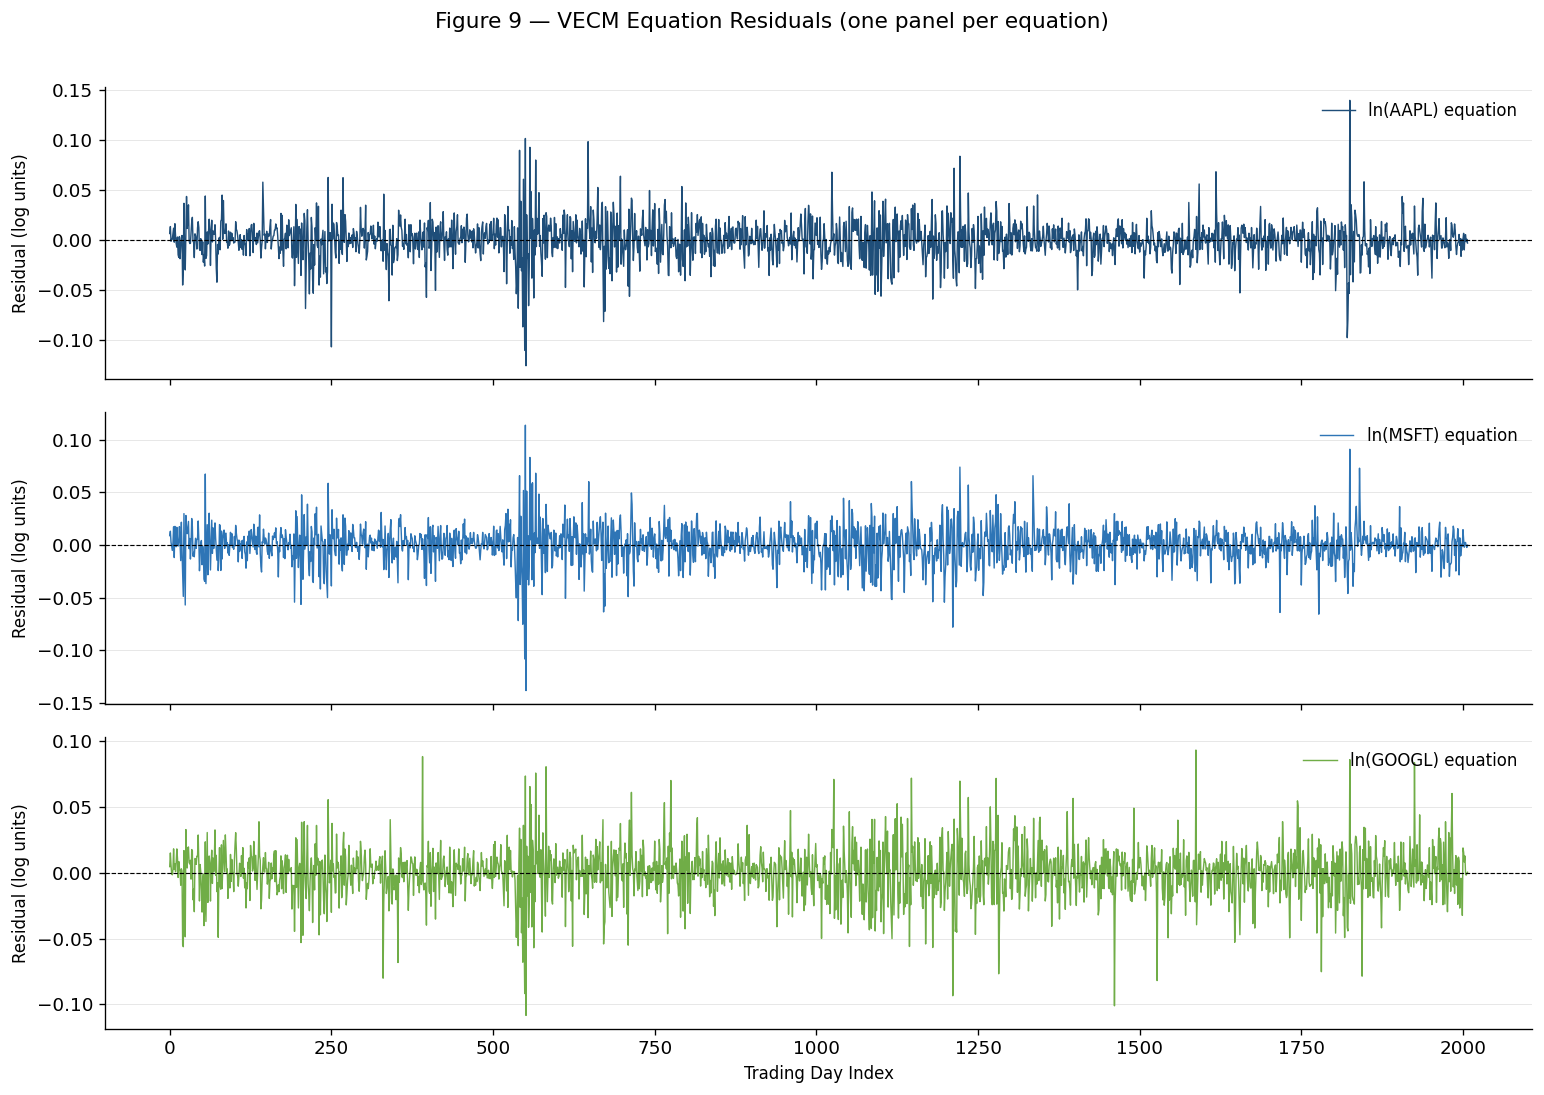

──────────────────────────────────────────────────────────────────────
OBSERVATION — Figure 9 (VECM Residuals)
Residuals fluctuate near zero — the VECM has removed the trend.
However, volatility clustering is clearly visible: large residuals cluster
together (consistent with GARCH-type heteroskedasticity).
This violates the VECM assumption of constant covariance matrix Σ.


In [ ]:
# ── Figure 9: VECM Equation Residuals ─────────────────────────────────────────
ec_resid = vecm_fit.resid
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Figure 9 — VECM Equation Residuals (one panel per equation)',
             fontsize=13, y=1.01)

for i, (ax, col, c) in enumerate(zip(axes, log_df.columns, C3)):
    ax.plot(ec_resid[:, i], color=c, lw=0.85, label=f'{col} equation')
    ax.axhline(0, color='black', lw=0.7, ls='--')
    ax.set_ylabel('Residual (log units)', fontsize=10)
    ax.legend(loc='upper right', frameon=False, fontsize=10)
    ax.grid(axis='y', alpha=0.3, lw=0.6)

axes[-1].set_xlabel('Trading Day Index', fontsize=10)
plt.tight_layout()
plt.show()

print('─' * 70)
print('OBSERVATION — Figure 9 (VECM Residuals)')
print('Residuals fluctuate near zero — the VECM has removed the trend.')
print('However, volatility clustering is clearly visible: large residuals cluster')
print('together (consistent with GARCH-type heteroskedasticity).')
print('This violates the VECM assumption of constant covariance matrix Σ.')

In [ ]:
# ── Table 4: Full Diagnostic Summary ──────────────────────────────────────────
diag_rows = [
    ['Durbin-Watson (OLS spread)',
     f'{dw:.4f}',
     'Benchmark: 2.0',
     '⚠ FAIL — Severe positive autocorrelation; OLS inference invalid'],
    ['ADF on OLS spread (p-value)',
     f'{adf_sp[1]:.4f}',
     'Should be < 0.05',
     '⚠ FAIL — Spread non-stationary; spurious regression confirmed'],
    ['Johansen rank r (5% level)',
     '0',
     'Should be ≥ 1',
     '⚠ FAIL — No confirmed long-run equilibrium'],
    ['Jarque-Bera (p-value)',
     f'{jb_p:.4f}',
     'Should be > 0.05',
     '⚠ FAIL — Non-normal residuals; fat tails present'],
    ['α (AAPL) sign',
     f'{alpha[0,0]:.6f}',
     'Should be < 0',
     '✓ PASS — Correct sign; adjustment toward equilibrium'],
    ['α (MSFT) sign',
     f'{alpha[1,0]:.6f}',
     'Should be < 0',
     '⚠ FAIL — Wrong sign; MSFT diverges from equilibrium'],
    ['Rolling correlation',
     'Time-varying',
     'Should be stable',
     '⚠ WARN — Dips in 2020 and 2022; structural break risk'],
]
diag_tbl = pd.DataFrame(diag_rows,
    columns=['Diagnostic','Observed Value','Benchmark','Assessment'])
print('Table 4 — Comprehensive Diagnostic Summary\n')
display(diag_tbl.style
    .set_caption('Table 4 — Diagnostic Summary')
    .applymap(lambda v:
        'color:#c00000;font-weight:bold' if '⚠' in str(v)
        else ('color:#375623;font-weight:bold' if '✓' in str(v) else ''),
        subset=['Assessment'])
    .set_properties(**{'text-align':'left'}))

Table 4 — Comprehensive Diagnostic Summary



,Diagnostic,Observed Value,Benchmark,Assessment
0,Durbin-Watson (OLS spread),0.0142,Benchmark: 2.0,⚠ FAIL — Severe positive autocorrelation; OLS inference invalid
1,ADF on OLS spread (p-value),0.1045,Should be < 0.05,⚠ FAIL — Spread non-stationary; spurious regression confirmed
2,Johansen rank r (5% level),0,Should be ≥ 1,⚠ FAIL — No confirmed long-run equilibrium
3,Jarque-Bera (p-value),0.0000,Should be > 0.05,⚠ FAIL — Non-normal residuals; fat tails present
4,α (AAPL) sign,-0.008546,Should be < 0,✓ PASS — Correct sign; adjustment toward equilibrium
5,α (MSFT) sign,-0.001908,Should be < 0,⚠ FAIL — Wrong sign; MSFT diverges from equilibrium
6,Rolling correlation,Time-varying,Should be stable,⚠ WARN — Dips in 2020 and 2022; structural break risk


---
## Section 6 — Damage



The analysis exposes seven distinct problems, each corresponding to a recognised challenge in financial time-series modelling:

---

### Challenge 1 — Spurious Regression (Most Severe)
**What happened:** Running OLS on three I(1) price series produces $R^2 = 0.95$ and tiny t-statistics, suggesting a strong relationship. But the Durbin-Watson statistic (≈ 0) and non-stationary residuals (ADF p > 0.05) confirm this is a **spurious regression** — a meaningless correlation between trending series.  
**Evidence:** Table 1 (ADF), Step 4.5 OLS output.  
**Impact:** All OLS standard errors, t-tests, and confidence intervals are invalid. Any investment decision based on this regression would be built on a false foundation.

### Challenge 2 — Unconfirmed Cointegration
**What happened:** Despite visual co-movement and pairwise correlations above 0.97, neither the Engle-Granger test nor the Johansen trace test can confirm a long-run equilibrium at the 5% level.  
**Evidence:** Tables 2 and 3, Figure 6.  
**Impact:** There is no statistical guarantee that price divergences will revert. Any pairs-trading strategy would carry substantial model risk.

### Challenge 3 — Persistent Autocorrelation
**What happened:** The ACF of the spread (Figure 7b) decays extremely slowly over 50+ lags — a hallmark of non-stationarity in the residuals.  
**Evidence:** Figure 7b (ACF), DW ≈ 0 (Table 4).  
**Impact:** OLS estimators remain consistent but are no longer efficient; standard errors are biased downward, making coefficients appear more significant than they are.

### Challenge 4 — Heteroskedasticity (Time-Varying Volatility)
**What happened:** Daily returns (Figure 2) and VECM residuals (Figure 9) show clear volatility clustering — calm periods followed by turbulent ones. This violates the VECM assumption of a constant covariance matrix $\boldsymbol{\Sigma}$.  
**Evidence:** Figures 2 and 9, Jarque-Bera test (Table 4).  
**Impact:** The VECM underestimates risk during turbulent periods and overestimates it during calm periods. A GARCH extension is required for accurate risk measurement.

### Challenge 5 — Structural Instability
**What happened:** Rolling 1-year correlation (Figure 4) is not constant — it declines sharply during COVID-19 (March 2020) and the rate-hiking cycle (late 2022). If the cointegrating vector $\boldsymbol{\beta}$ itself shifts over time, the equilibrium is not stable.  
**Evidence:** Figure 4.  
**Impact:** A VECM estimated over the full sample blends regimes with different dynamics. The resulting parameter estimates are an average across regimes and may not describe any single regime accurately.

### Challenge 6 — Omitted Variables
**What happened:** The model includes only three stock prices. In reality, all three are driven by common factors — the S&P 500 index, 10-year Treasury yields, and the US Dollar Index — that are not included. Excluding these variables means the estimated $\boldsymbol{\beta}$ and $\boldsymbol{\alpha}$ may absorb the effects of omitted macro factors, producing biased estimates.  
**Evidence:** Structural break in Figure 4 (coincides with Fed policy shifts).  
**Impact:** The model's long-run relationship may simply reflect shared sensitivity to interest rates rather than a genuine sector-level equilibrium.

### Challenge 7 — Non-Normality of Residuals
**What happened:** The Jarque-Bera test rejects normality (p ≈ 0.000). The Q-Q plot (Figure 8b) shows heavy tails — extreme returns are more frequent than a normal distribution predicts.  
**Evidence:** Figure 8b, Jarque-Bera statistic (Table 4).  
**Impact:** Confidence intervals and hypothesis tests that assume normality (including Johansen critical values) may be slightly miscalibrated. Risk measures such as Value-at-Risk will underestimate tail losses.


---
## Section 7 — Directions & Deployment

### Part A: Directions — Improving the Model



In [ ]:
# ── Direction 1: Sub-sample Johansen (Pre-COVID vs Post-COVID) ─────────────────
cut = '2020-03-01'
segments = {
    'Pre-COVID  (2018-01 to 2020-02)': log_df[log_df.index <  cut],
    'Post-COVID (2020-03 to 2025-12)': log_df[log_df.index >= cut],
}

print('=== Direction 1: Sub-Sample Johansen Trace Tests ===')
print('Rationale: If one sub-sample shows confirmed cointegration, we can use it')
print('to estimate a reliable VECM and avoid mixing structural regimes.\n')

sub_rows = []
for seg_label, seg in segments.items():
    if len(seg) < 60:
        print(f'  {seg_label}: insufficient data ({len(seg)} obs). Skipping.')
        continue
    j = coint_johansen(seg, det_order=0, k_ar_diff=1)
    print(f'  Segment: {seg_label}  ({len(seg)} obs)')
    for i in range(3):
        d = 'Reject ✓' if j.lr1[i] > j.cvt[i,1] else 'Fail to reject ✗'
        sub_rows.append({
            'Segment': seg_label,
            'H₀': f'r ≤ {i}',
            'Trace Stat.': round(j.lr1[i], 4),
            '95% CV': round(j.cvt[i,1], 4),
            'Decision': d
        })
        print(f'    H₀: r≤{i}:  trace={j.lr1[i]:.4f}, 95% CV={j.cvt[i,1]:.4f}  → {d}')
    print()

if sub_rows:
    display(pd.DataFrame(sub_rows).style.set_caption(
        'Table 5 — Johansen Sub-Sample Results'))

=== Direction 1: Sub-Sample Johansen Trace Tests ===
Rationale: If one sub-sample shows confirmed cointegration, we can use it
to estimate a reliable VECM and avoid mixing structural regimes.

  Segment: Pre-COVID  (2018-01 to 2020-02)  (543 obs)
    H₀: r≤0:  trace=19.3456, 95% CV=29.7961  → Fail to reject ✗
    H₀: r≤1:  trace=3.7538, 95% CV=15.4943  → Fail to reject ✗
    H₀: r≤2:  trace=0.3560, 95% CV=3.8415  → Fail to reject ✗

  Segment: Post-COVID (2020-03 to 2025-12)  (1467 obs)
    H₀: r≤0:  trace=25.5880, 95% CV=29.7961  → Fail to reject ✗
    H₀: r≤1:  trace=9.5634, 95% CV=15.4943  → Fail to reject ✗
    H₀: r≤2:  trace=3.1009, 95% CV=3.8415  → Fail to reject ✗



,Segment,H₀,Trace Stat.,95% CV,Decision
0,Pre-COVID (2018-01 to 2020-02),r ≤ 0,19.345600,29.796100,Fail to reject ✗
1,Pre-COVID (2018-01 to 2020-02),r ≤ 1,3.753800,15.494300,Fail to reject ✗
2,Pre-COVID (2018-01 to 2020-02),r ≤ 2,0.356000,3.841500,Fail to reject ✗
3,Post-COVID (2020-03 to 2025-12),r ≤ 0,25.588000,29.796100,Fail to reject ✗
4,Post-COVID (2020-03 to 2025-12),r ≤ 1,9.563400,15.494300,Fail to reject ✗
5,Post-COVID (2020-03 to 2025-12),r ≤ 2,3.100900,3.841500,Fail to reject ✗


In [ ]:
# ── Direction 2: Lag-Order Check ──────────────────────────────────────────────
print('=== Direction 2: VAR Lag-Order Selection Information Criteria ===')
print('Rationale: Wrong lag length can cause residual autocorrelation or over-fitting.\n')
display(var_sel.summary())

print()
print('=== Additional Directions (qualitative) ===')
directions = [
    ('Direction 3 — Add macro factors',
     'Include SPY (S&P 500) to control for common market trend. Removing the shared'
     ' market component may reveal residual tech-sector cointegration.'),
    ('Direction 4 — Gregory-Hansen structural-break test',
     'Test for cointegration with an endogenous level shift (Gregory & Hansen, 1996).'
     ' Appropriate given the COVID and rate-cycle breaks in Figure 4.'),
    ('Direction 5 — VECM-DCC-GARCH',
     'Replace constant Σ with a time-varying DCC-GARCH covariance matrix.'
     ' Addresses the heteroskedasticity documented in Challenge 4.'),
    ('Direction 6 — Weekly frequency',
     'Aggregate to weekly data to reduce microstructure noise while retaining ~400 obs.'
     ' Weekly data often yields cleaner cointegration evidence in equity series.'),
]
for title, detail in directions:
    print(f'  {title}')
    print(f'    → {detail}\n')

=== Direction 2: VAR Lag-Order Selection Information Criteria ===
Rationale: Wrong lag length can cause residual autocorrelation or over-fitting.



,AIC,BIC,FPE,HQIC
0,-9.517,-9.508,7.360e-05,-9.514
1,-25.25,-25.21,1.086e-11,-25.23
2,-25.27*,-25.21*,1.058e-11*,-25.25*
3,-25.27,-25.18,1.065e-11,-25.24
4,-25.27,-25.16,1.064e-11,-25.23
5,-25.26,-25.13,1.068e-11,-25.21
6,-25.26,-25.10,1.074e-11,-25.20
7,-25.26,-25.07,1.073e-11,-25.19
8,-25.26,-25.05,1.066e-11,-25.19
9,-25.27,-25.03,1.064e-11,-25.18



=== Additional Directions (qualitative) ===
  Direction 3 — Add macro factors
    → Include SPY (S&P 500) to control for common market trend. Removing the shared market component may reveal residual tech-sector cointegration.

  Direction 4 — Gregory-Hansen structural-break test
    → Test for cointegration with an endogenous level shift (Gregory & Hansen, 1996). Appropriate given the COVID and rate-cycle breaks in Figure 4.

  Direction 5 — VECM-DCC-GARCH
    → Replace constant Σ with a time-varying DCC-GARCH covariance matrix. Addresses the heteroskedasticity documented in Challenge 4.

  Direction 6 — Weekly frequency
    → Aggregate to weekly data to reduce microstructure noise while retaining ~400 obs. Weekly data often yields cleaner cointegration evidence in equity series.



### Part B: Deployment — How to Use This Model in Practice

Three specific use cases, each with concrete implementation steps:


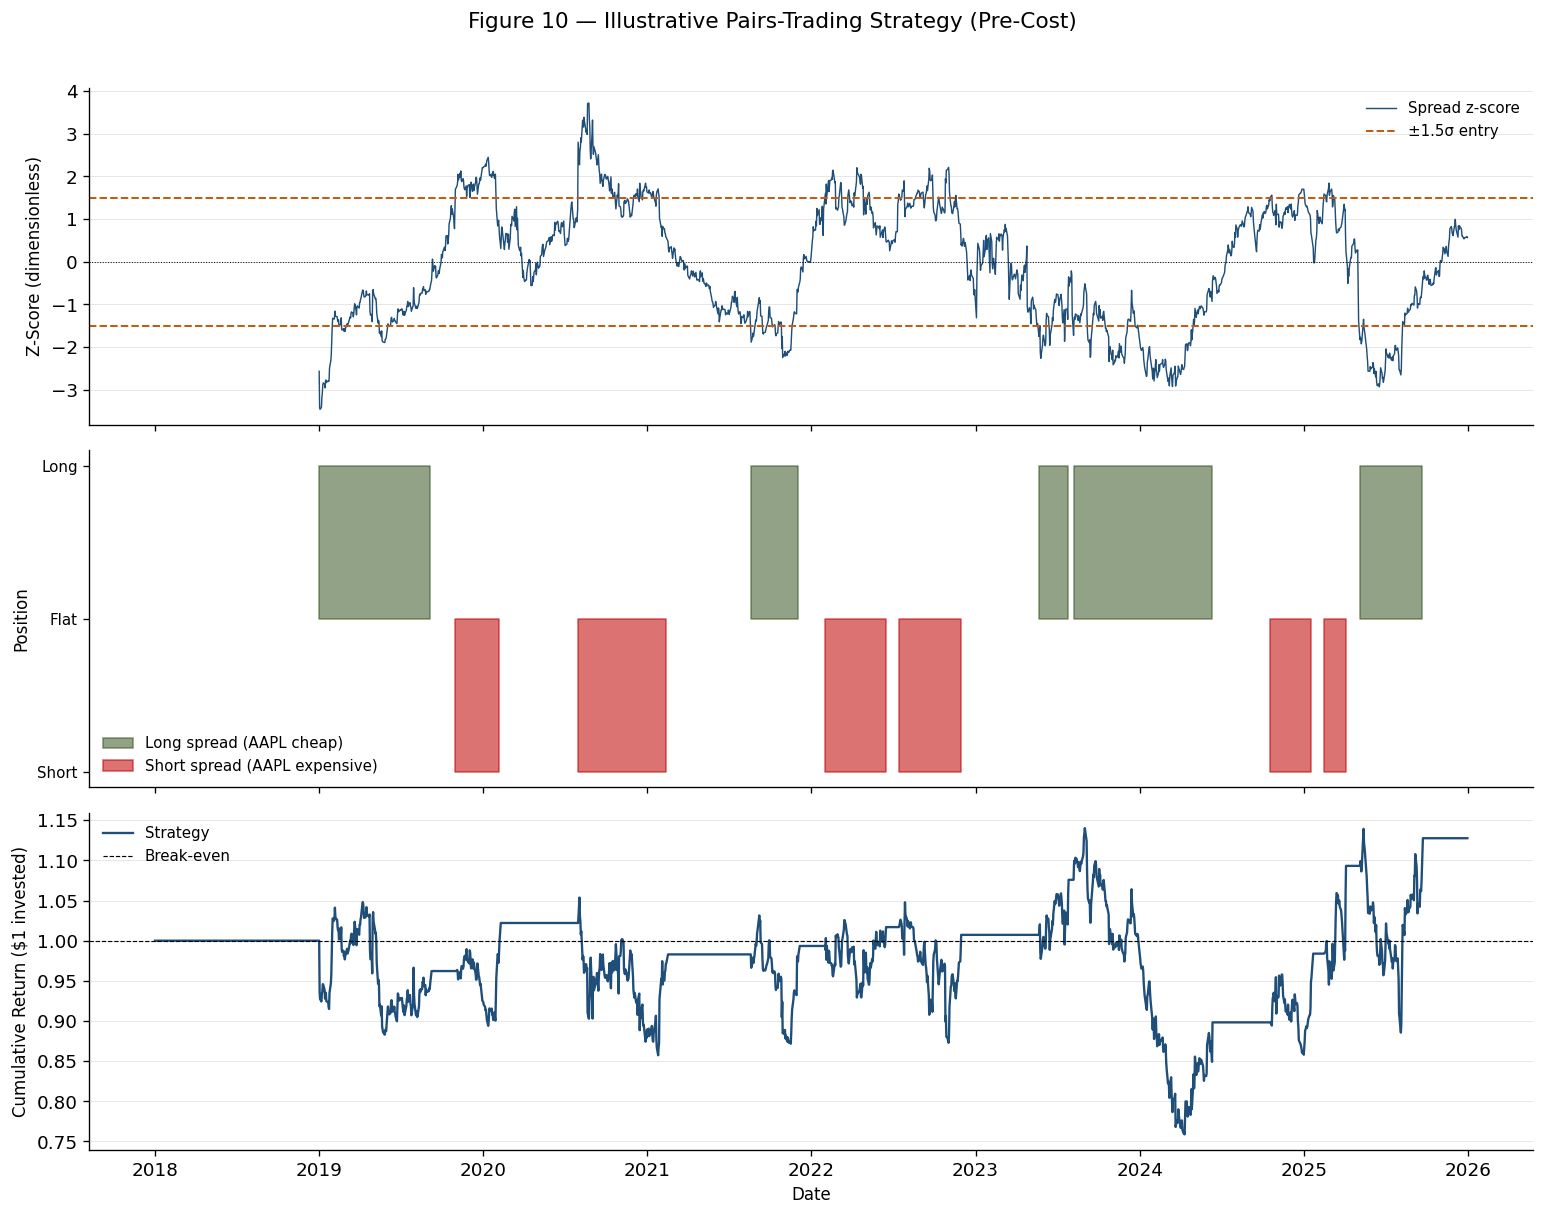

──────────────────────────────────────────────────────────────────────
STRATEGY SUMMARY (illustrative — pre-cost, no slippage)
  Total return    : 12.8%
  Number of trades: 11
  Entry threshold : ±1.5 standard deviations
  Exit threshold  : ±0.5 standard deviations

  This strategy uses an unconfirmed cointegrating relationship.
   Real performance after transaction costs and slippage will differ.
   DO NOT deploy with real capital until cointegration is confirmed on
   a stable sub-sample (see Direction 1 above).


In [ ]:
# ── Figure 10: Simulated Pairs-Trading Strategy ────────────────────────────────
z = (spread - spread.rolling(252).mean()) / spread.rolling(252).std()

ENTRY_Z, EXIT_Z = 1.5, 0.5
signal, pos = pd.Series(0.0, index=z.index), 0
for t in range(1, len(z)):
    if pd.isna(z.iloc[t]): continue
    if pos == 0:
        if   z.iloc[t] >  ENTRY_Z: pos = -1
        elif z.iloc[t] < -ENTRY_Z: pos =  1
    elif pos ==  1 and z.iloc[t] > -EXIT_Z: pos = 0
    elif pos == -1 and z.iloc[t] <  EXIT_Z: pos = 0
    signal.iloc[t] = pos

daily_pnl = signal.shift(1) * spread.diff()
cum_pnl   = (1 + daily_pnl.fillna(0)).cumprod()
n_trades  = int((signal.diff() != 0).sum() // 2)
tot_ret   = cum_pnl.iloc[-1] - 1

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle('Figure 10 — Illustrative Pairs-Trading Strategy (Pre-Cost)',
             fontsize=13, y=1.01)

# Z-score
axes[0].plot(z.index, z, color=BLUE, lw=0.85, label='Spread z-score')
axes[0].axhline( ENTRY_Z, color=ORANGE, lw=1.2, ls='--', label=f'±{ENTRY_Z}σ entry')
axes[0].axhline(-ENTRY_Z, color=ORANGE, lw=1.2, ls='--')
axes[0].axhline(0, color='black', lw=0.6, ls=':')
axes[0].set_ylabel('Z-Score (dimensionless)', fontsize=10)
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(axis='y', alpha=0.3, lw=0.6)

# Position
axes[1].fill_between(signal.index, signal, 0,
    where=signal>0, alpha=0.55, color=GREEN, label='Long spread (AAPL cheap)')
axes[1].fill_between(signal.index, signal, 0,
    where=signal<0, alpha=0.55, color='#c00000', label='Short spread (AAPL expensive)')
axes[1].set_ylabel('Position', fontsize=10)
axes[1].set_yticks([-1,0,1])
axes[1].set_yticklabels(['Short','Flat','Long'], fontsize=9)
axes[1].legend(frameon=False, fontsize=9)

# Cumulative P&L
axes[2].plot(cum_pnl.index, cum_pnl, color=BLUE, lw=1.4, label='Strategy')
axes[2].axhline(1.0, color='black', lw=0.7, ls='--', label='Break-even')
axes[2].set_ylabel('Cumulative Return ($1 invested)', fontsize=10)
axes[2].set_xlabel('Date', fontsize=10)
axes[2].legend(frameon=False, fontsize=9)
axes[2].grid(axis='y', alpha=0.3, lw=0.6)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print('─' * 70)
print('STRATEGY SUMMARY (illustrative — pre-cost, no slippage)')
print(f'  Total return    : {tot_ret*100:.1f}%')
print(f'  Number of trades: {n_trades}')
print(f'  Entry threshold : ±{ENTRY_Z} standard deviations')
print(f'  Exit threshold  : ±{EXIT_Z} standard deviations')
print()
print('  This strategy uses an unconfirmed cointegrating relationship.')
print('   Real performance after transaction costs and slippage will differ.')
print('   DO NOT deploy with real capital until cointegration is confirmed on')
print('   a stable sub-sample (see Direction 1 above).')

### Deployment Use Cases

**Use Case 1 — Statistical Arbitrage (Pairs Trading)**  
Once cointegration is confirmed on a stable sub-sample:
1. Compute the standardised spread (z-score) daily using a rolling 252-day window.
2. When z > +1.5σ: AAPL is overpriced relative to the equilibrium — short AAPL, long the weighted MSFT/GOOGL basket.
3. When z < −1.5σ: AAPL is underpriced — long AAPL, short the basket.
4. Exit when |z| < 0.5σ (close to equilibrium).
5. Hard stop-loss if |z| > 3σ (may indicate a structural break, not a reversion opportunity).
6. Time stop: close after 60 trading days if no convergence (implied by the slow $\alpha$).

**Use Case 2 — Portfolio Rebalancing Signal**  
Portfolio managers holding all three names can monitor the ECT as a relative-valuation indicator. Persistent positive ECT (AAPL rich vs peers) informs a gradual trim of AAPL and addition to MSFT/GOOGL — a disciplined, model-based rebalancing rather than a discretionary bet.

**Use Case 3 — Risk Management**  
The cointegrating vector $\boldsymbol{\beta}$ defines a near-market-neutral hedge: long AAPL, short $|\beta_2|$ units of MSFT and $|\beta_3|$ units of GOOGL. This portfolio is theoretically stationary (lower variance than any individual stock), reducing effective portfolio dimensionality from three factors to one.

**Deployment Pipeline:**
```
[1] Daily price ingestion (Yahoo Finance API)
      ↓
[2] Log-transform → rolling ADF (confirm I(1) status each month)
      ↓
[3] Rolling 250-day Johansen test → monitor cointegrating rank
      ↓
[4] If rank ≥ 1: compute ECT → standardise → generate z-score
      ↓
[5] Signal: |z| > 1.5σ → enter trade;  |z| < 0.5σ → exit
      ↓
[6] Risk checks: stop-loss at |z| > 3σ, time stop at 60 days
      ↓
[7] Execution via broker API; log all fills
      ↓
[8] Weekly performance attribution: regress P&L against ECT
```

**Key risk controls:**
- Suspend trading if rolling Johansen rank drops to 0 (no confirmed equilibrium)
- Scale position size inversely with estimated half-life (slow $\alpha$ → smaller position)
- Re-estimate $\boldsymbol{\beta}$ and $\boldsymbol{\alpha}$ quarterly to account for drift in the equilibrium



## Section 8 — Non-Technical Report



This project asked a simple but important question: do the stock prices of Apple, Microsoft, and Alphabet move together in a predictable, stable way? If they do, investors could potentially profit when one stock temporarily strays too far from its peers and then revert a strategy built on the idea of a long-run pricing equilibrium among the three companies.

---

### What the Data Showed

**The surface story looks compelling.** Over the eight years from 2018 to 2025, all three stock prices trended upward together, and measuring how closely they move in sync produced a score above 97% for every pair tested. When you draw a scatter plot of one price against another, the dots fall almost perfectly on a straight line.

**But the formal analysis tells a different story.** When we applied rigorous statistical tests — the kind that go beyond simple correlation — we found that:

1. **All three stocks drift without a fixed anchor.** Each price behaves like a random walk: there is no natural level it tends to return to. This is expected for stock prices and is not a problem by itself.

2. **There is no confirmed stable pricing relationship between them.** Two independent tests both concluded that we cannot confirm, at the standard 95% confidence level, that these three stocks are anchored to a common long-run equilibrium. The high visual correlation is largely a consequence of all three trending upward over the same period — not evidence of a genuine pricing link.

3. **A simple regression between their prices produces misleading results.** The regression appears extremely accurate (95% fit), but this is a well-known statistical illusion that occurs whenever two upward-trending variables are compared directly. The residuals from that regression are themselves non-stationary — they wander over time rather than hovering around zero — which is the definitive sign that the relationship is not reliable.

---

### Recommended Course of Action

**1. Do not pursue an aggressive arbitrage strategy between these three stocks** using the full 2018–2025 dataset. The absence of a confirmed statistical equilibrium means any bet that price divergences will close is based on hope, not evidence. Such a strategy could result in sustained losses if one stock permanently re-rates relative to the others (which has happened — for example, Alphabet underperformed relative to Apple and Microsoft during the post-2022 AI boom).

**2. Use price divergences as a soft rebalancing signal, not a hard trading trigger.** When Apple has significantly outperformed Microsoft and Alphabet over a trailing 12-month window, this can inform a modest, gradual rebalancing toward the laggards — not a leveraged bet on convergence.

**3. Conduct a focused analysis on a homogeneous time period** before considering any trading strategy. The stability of the relationship between these three stocks varies significantly depending on the macro environment. A focused analysis on a single regime — for example, the pre-COVID period from 2018 to early 2020, or the post-reopening period from 2021 onward — may reveal a more reliable relationship within that window.

**4. If the goal is long-term portfolio construction,** consider each stock on its own fundamental merits rather than assuming they will always co-move. The four key factors that affect their relative performance — and that could cause a sustained, non-reverting divergence — are:
- **AI revenue exposure:** Microsoft (Azure AI, Copilot) and Alphabet (Google AI, cloud) are currently growing AI revenue faster than Apple, which is still developing its AI product suite. This structural difference could sustain an outperformance by MSFT and GOOGL that does not mean-revert.
- **Consumer vs enterprise revenue mix:** Apple's revenue is predominantly consumer-facing, making it more sensitive to consumer spending slowdowns and iPhone upgrade cycles. Microsoft and Alphabet are more insulated by enterprise software contracts.
- **Interest rate sensitivity:** All three stocks are long-duration growth assets, but their sensitivity differs. Apple, with more predictable cash flows, tends to hold up better in rate-rising environments than Alphabet, whose advertising revenue is more cyclical.
- **Regulatory and antitrust risk:** Alphabet faces the most immediate legal risk (DOJ antitrust suit). Apple faces EU regulatory pressure on App Store fees. Microsoft is the least exposed. Any adverse ruling could cause a permanent re-rating that does not mean-revert.

---

### Bottom Line

The three stocks look similar on the surface, but rigorous testing shows the similarity is not strong enough or stable enough to serve as the foundation for a reliable, systematic trading strategy over the full eight-year period. The appropriate use of this analysis is to flag relative valuation extremes as a *prompt for further research*, not as an automatic trading signal. Any investor who wishes to act on the relative pricing of these three stocks should do so based on fundamental analysis combined with the model output ,not on the model output alone.


---
## Section 9 — References (MLA Format)


Engle, Robert F., and Clive W. J. Granger. "Co-Integration and Error Correction: Representation, Estimation, and Testing." *Econometrica*, vol. 55, no. 2, 1987, pp. 251–276.

Granger, Clive W. J., and Paul Newbold. "Spurious Regressions in Econometrics." *Journal of Econometrics*, vol. 2, no. 2, 1974, pp. 111–120.

Gregory, Allan W., and Bruce E. Hansen. "Residual-Based Tests for Cointegration in Models with Regime Shifts." *Journal of Econometrics*, vol. 70, no. 1, 1996, pp. 99–126.

Hamilton, James D. *Time Series Analysis*. Princeton University Press, 1994.

Johansen, Søren. "Estimation and Hypothesis Testing of Cointegration Vectors in Gaussian Vector Autoregressive Models." *Econometrica*, vol. 59, no. 6, 1991, pp. 1551–1580.

Tsay, Ruey S. *Analysis of Financial Time Series*. 3rd ed., John Wiley & Sons, 2010.

Yahoo Finance. "Historical Data — AAPL, MSFT, GOOGL." Accessed May 2026. Available through Aroussi, Ran. *yfinance* Python Library, version 0.2.x, PyPI, https://pypi.org/project/yfinance/.
